In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.linear_model import LinearRegression as lr
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb
from sklearn.utils import shuffle
from sklearn.metrics import roc_auc_score, roc_curve
import os
pd.set_option('display.max_columns', None)
import missingno as msno

In [2]:
import pandas as pd
import os

# 1. Directory path
folder_path = os.path.join('..', 'data', 'raw')

# 2. List ONLY files that contain 'historical' in the name and end with '.csv'
all_files = [
    f for f in os.listdir(folder_path) 
    if f.endswith('.csv') and 'historical' in f.lower()
]

print(f"Detected {len(all_files)} historical files. Starting the merging process...")

# 3. Create a list to store each individual DataFrame
data_frames = []

for filename in all_files:
    file_path = os.path.join(folder_path, filename)
    
    # Read the CSV file
    temp_df = pd.read_csv(file_path)
    
    # Extract the city name from the filename for identification
    # Example: 'baku_historical.csv' -> 'baku'
    city_name = filename.lower().replace('_historical.csv', '').replace('.csv', '')
    temp_df['city'] = city_name
    
    data_frames.append(temp_df)

# 4. Concatenate all DataFrames into one
if data_frames:
    # Use 'df' as the variable name to match your previous logic
    df = pd.concat(data_frames, ignore_index=True)

    # 5. Save the combined dataset with the specific name requested
    output_filename = 'all_94_cities_historical_combined.csv'
    output_path = os.path.join(folder_path, output_filename)
    
    # Actually write the file to the path (this was missing)
    df.to_csv(output_path, index=False)
    
    print(f"Success! Data merged into '{output_filename}'.")
    # Fixed: Using 'df' instead of 'df_combined' to match line 35
    print(f"Total rows in merged dataset: {len(df)}")
else:
    print("No historical CSV files found. Please check your folder path and filenames.")

Detected 94 historical files. Starting the merging process...
Success! Data merged into 'all_94_cities_historical_combined.csv'.
Total rows in merged dataset: 215928


# Task 1 — Data Quality Assessment

1.1) Missing values

--- 1. Missing Values ---
          temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
city                                                                    
absheron                 0.0                 0.0                  0.0   
agdam                    0.0                 0.0                  0.0   
agdash                   0.0                 0.0                  0.0   
agdere                   0.0                 0.0                  0.0   
agjabadi                 0.0                 0.0                  0.0   
...                      ...                 ...                  ...   
yerevan                  0.0                 0.0                  0.0   
yevlakh                  0.0                 0.0                  0.0   
zagatala                 0.0                 0.0                  0.0   
zangilan                 0.0                 0.0                  0.0   
zardab                   0.0                 0.0                  0.0   

          precipitation_

<Figure size 1200x600 with 0 Axes>

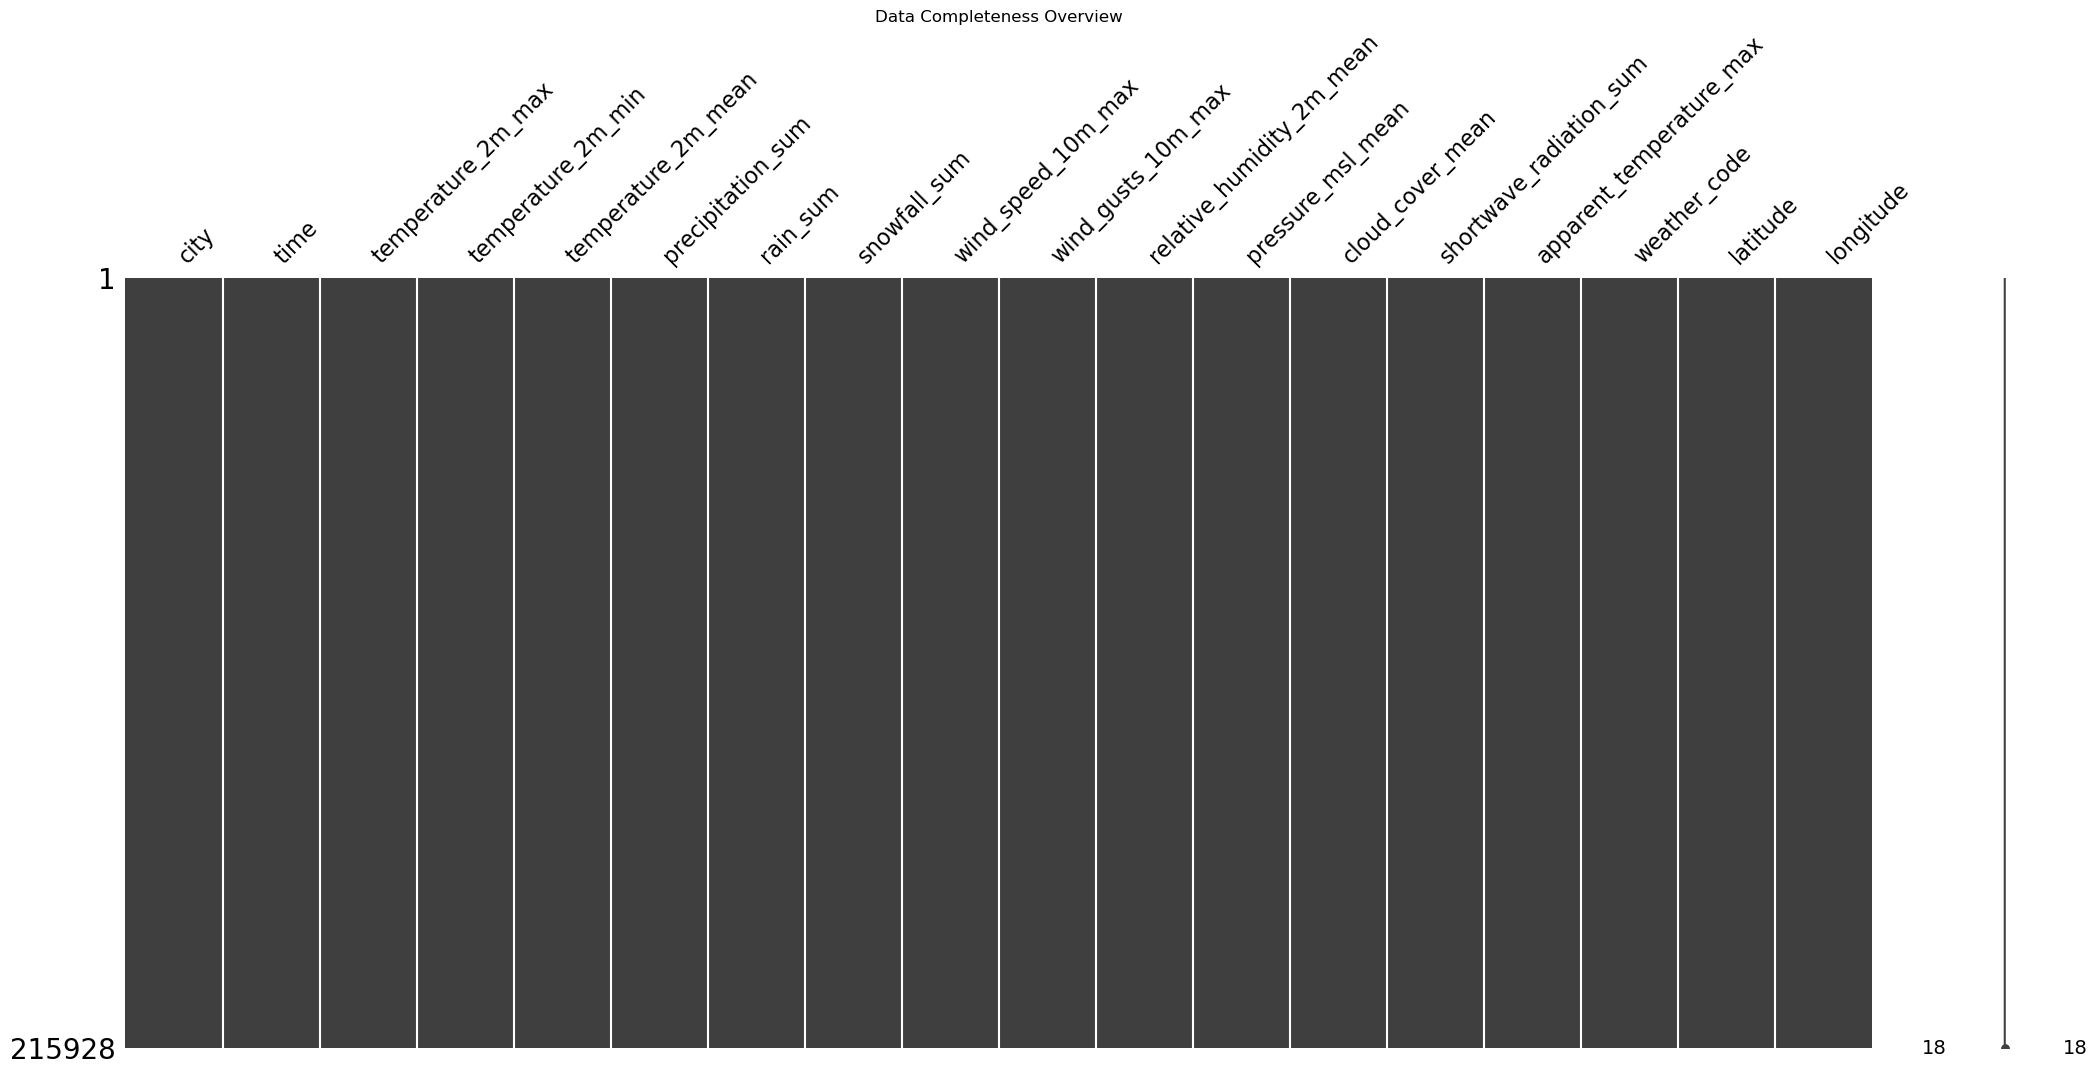

In [3]:
# List of all measurement columns based on your dtypes
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# --- 1. Missing Values Assessment ---
print("--- 1. Missing Values ---")
# Calculating null percentages grouped by city
null_analysis = df.groupby('city')[numerical_cols].apply(lambda x: x.isnull().mean() * 100)
print(null_analysis)

# Visualizing missing data patterns
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Data Completeness Overview")
plt.show()

1.2) Outliers


--- Outlier Report for: temperature_2m_max ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


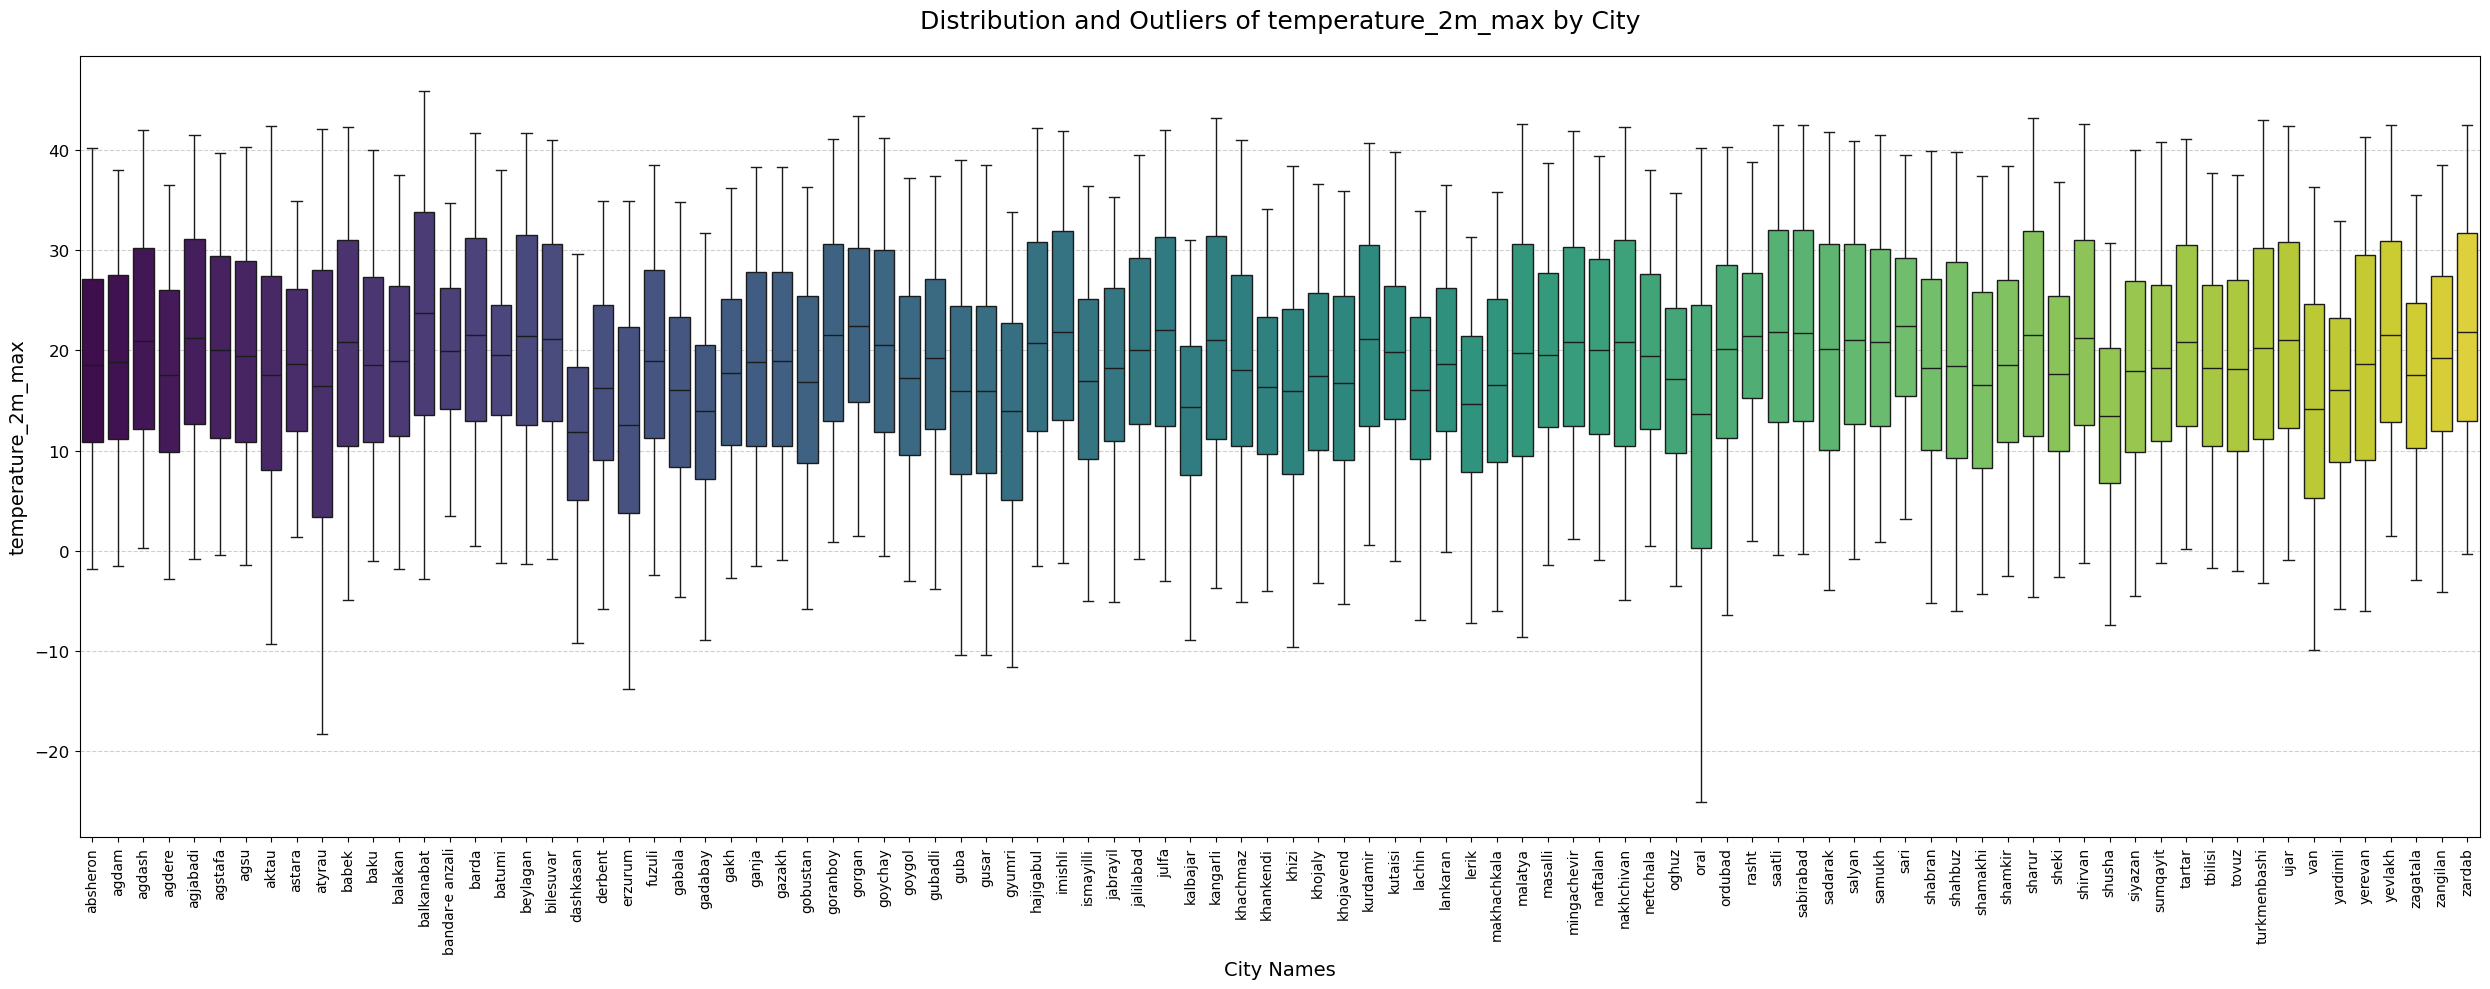


--- Outlier Report for: temperature_2m_min ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


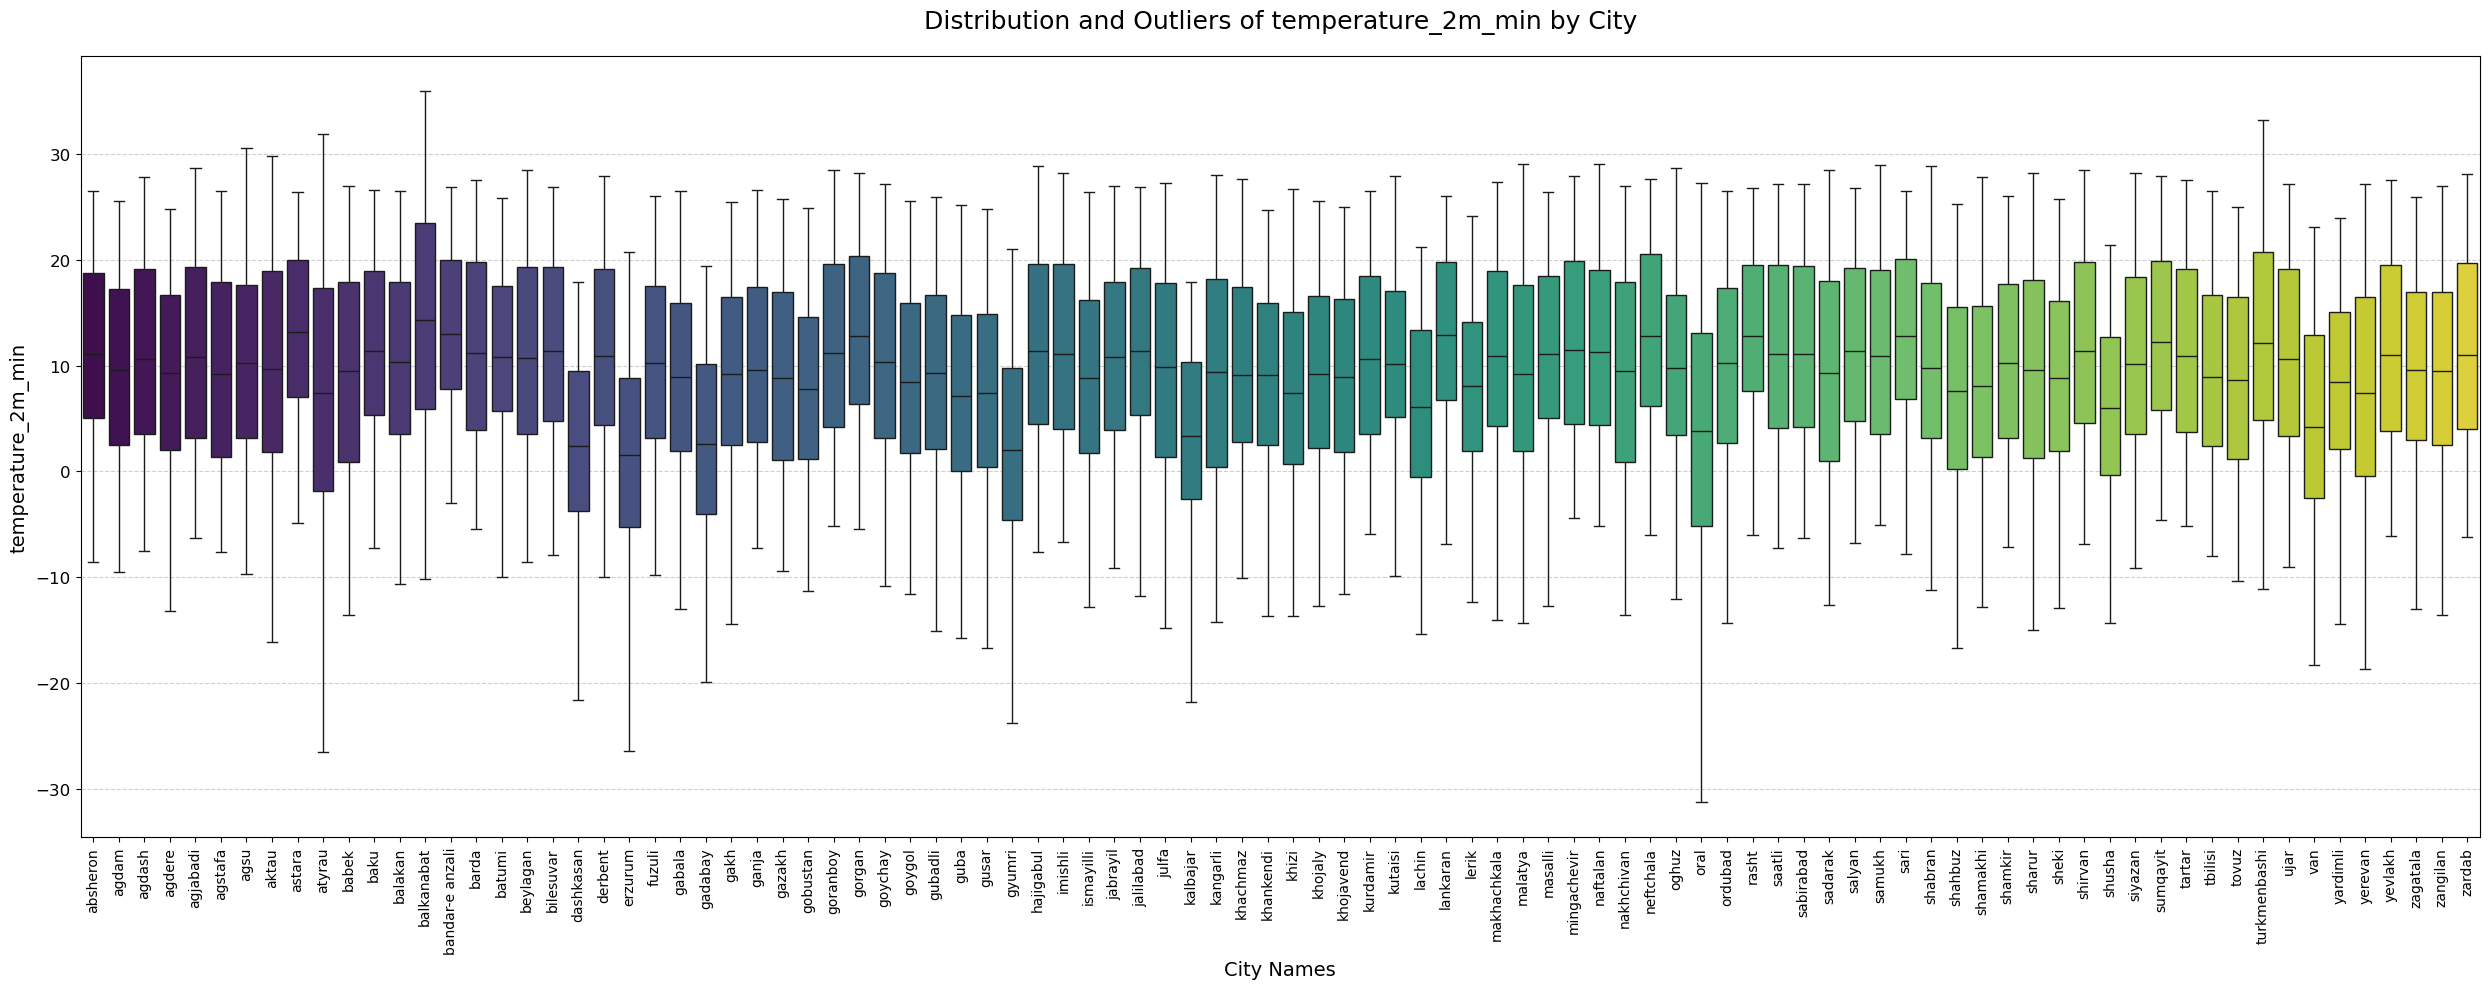


--- Outlier Report for: temperature_2m_mean ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


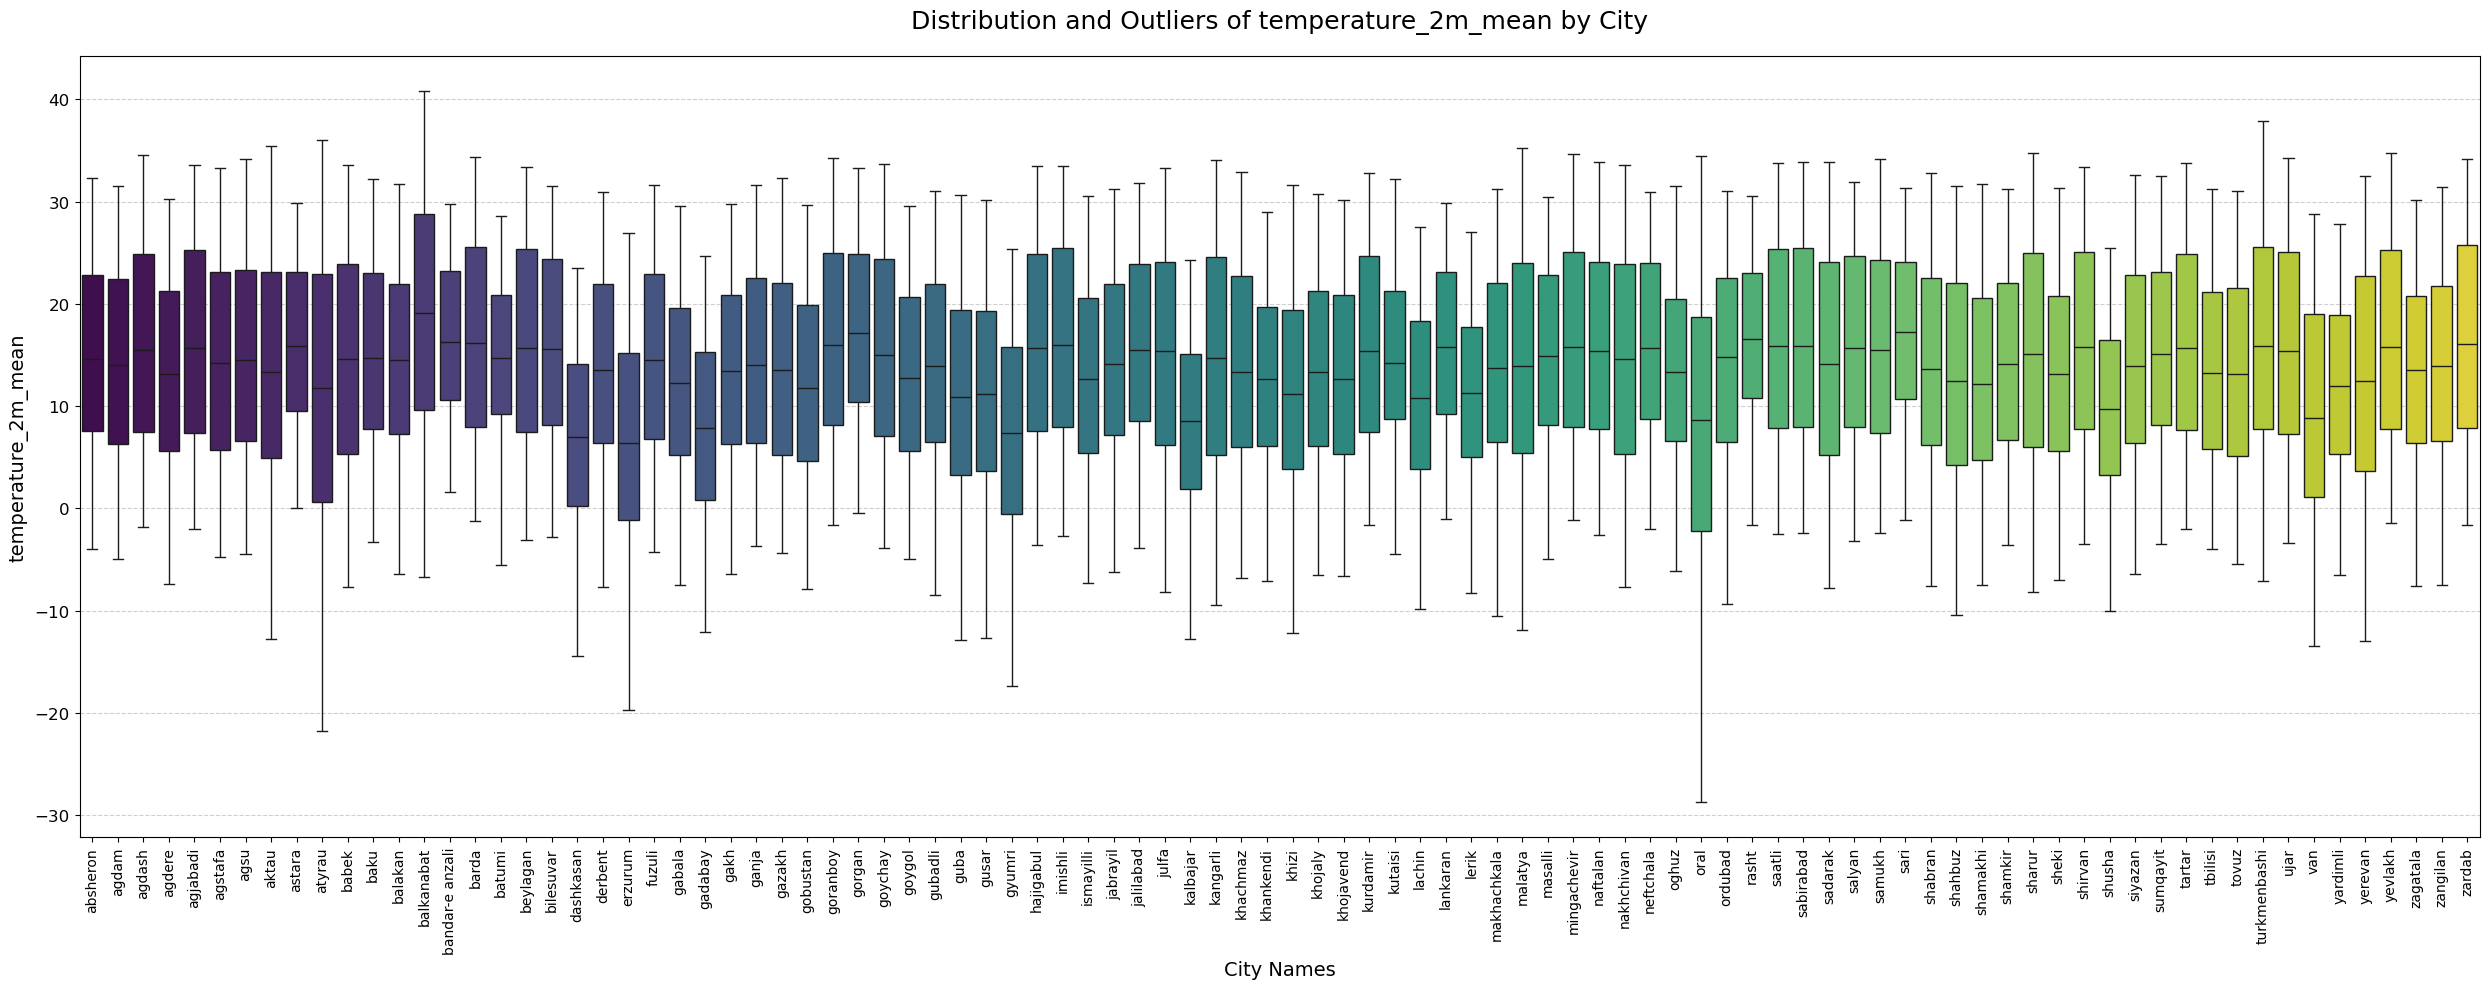


--- Outlier Report for: precipitation_sum ---
city
absheron    437
agdam       430
agdash      455
agdere      394
agjabadi    443
           ... 
yerevan     430
yevlakh     474
zagatala    385
zangilan    388
zardab      452
Name: precipitation_sum, Length: 94, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


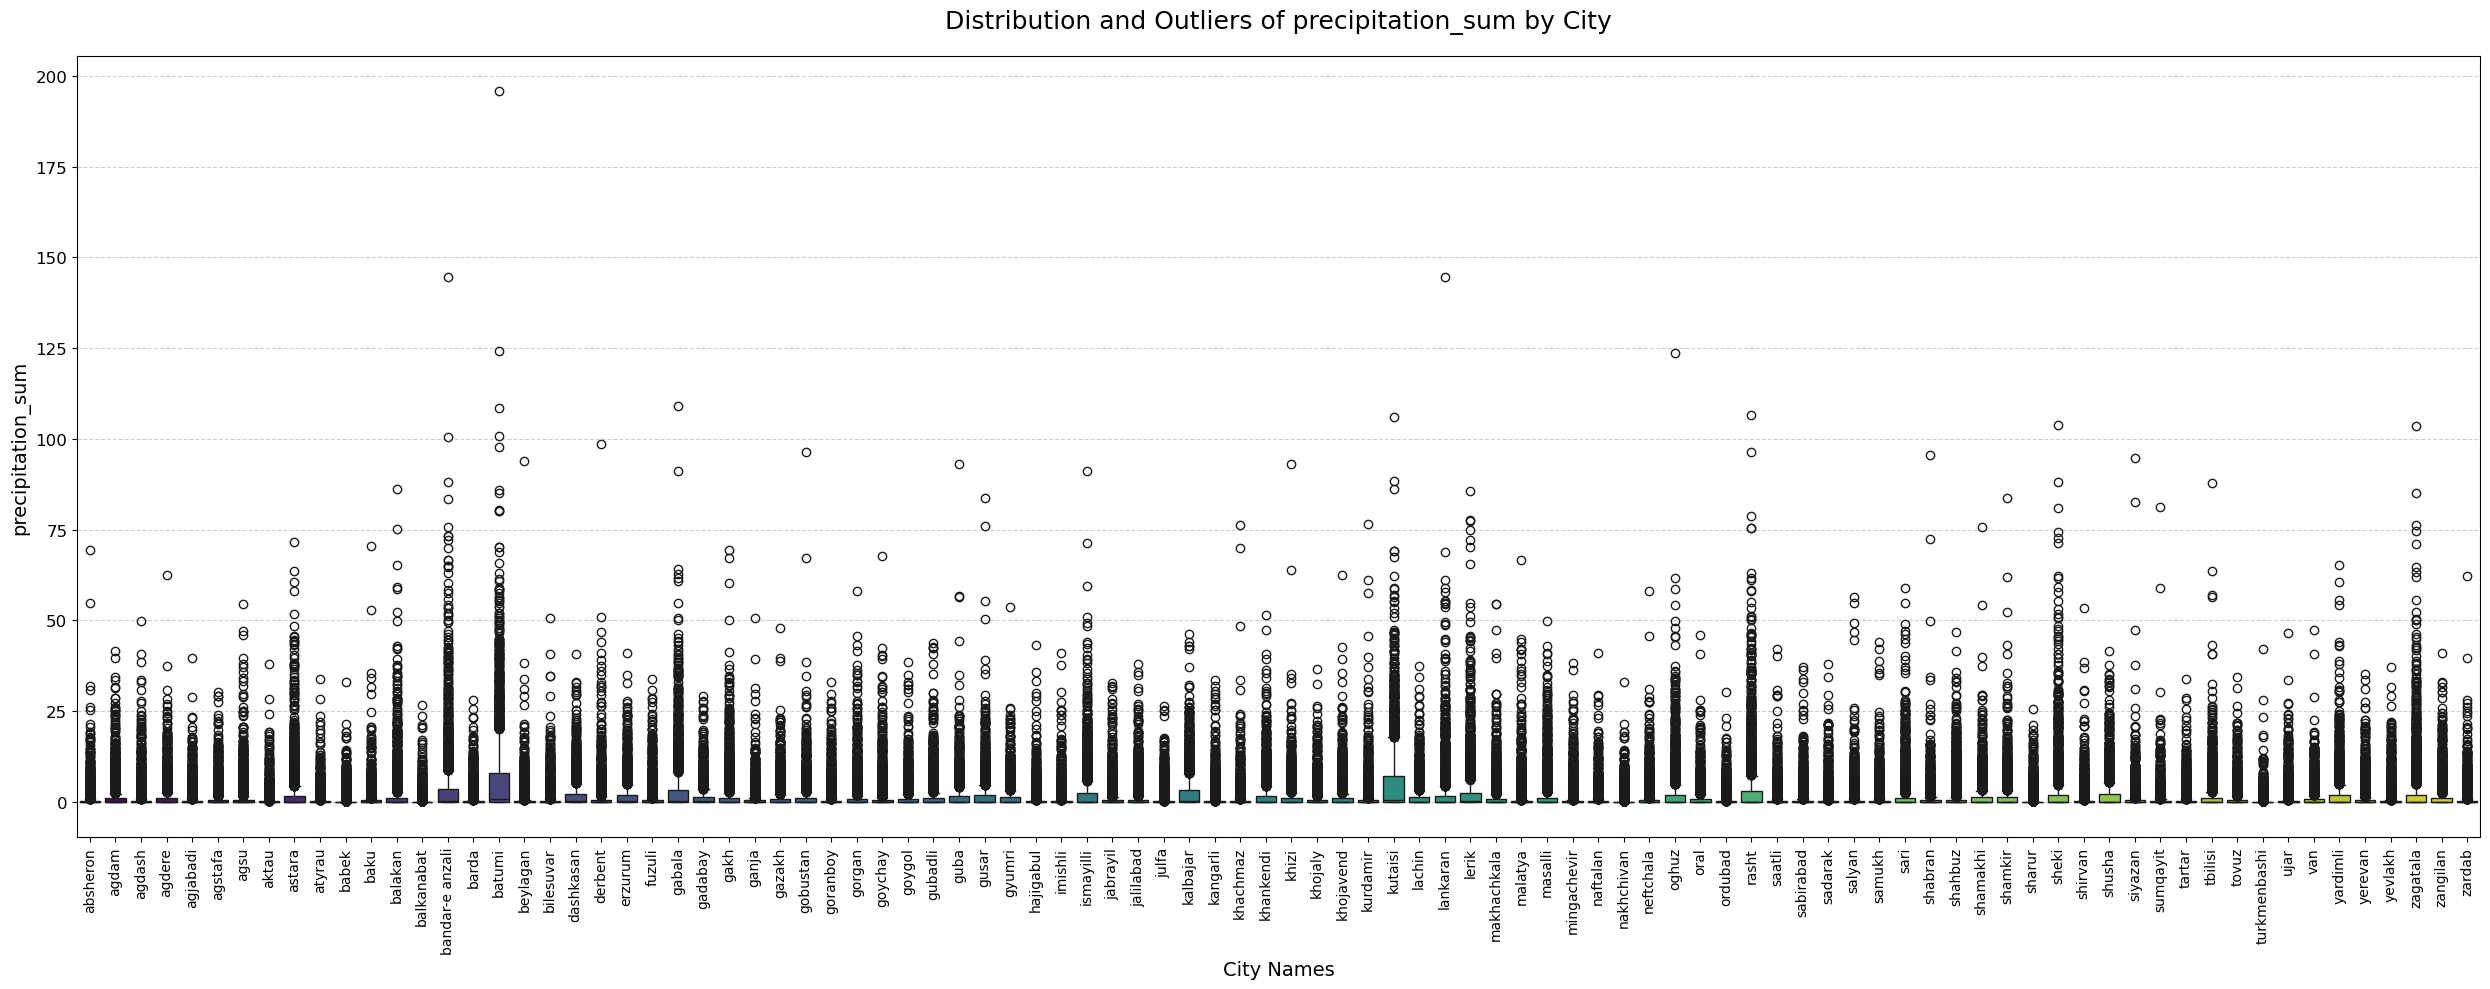


--- Outlier Report for: rain_sum ---
city
absheron    413
agdam       413
agdash      440
agdere      388
agjabadi    422
           ... 
yerevan     462
yevlakh     459
zagatala    409
zangilan    417
zardab      487
Name: rain_sum, Length: 94, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


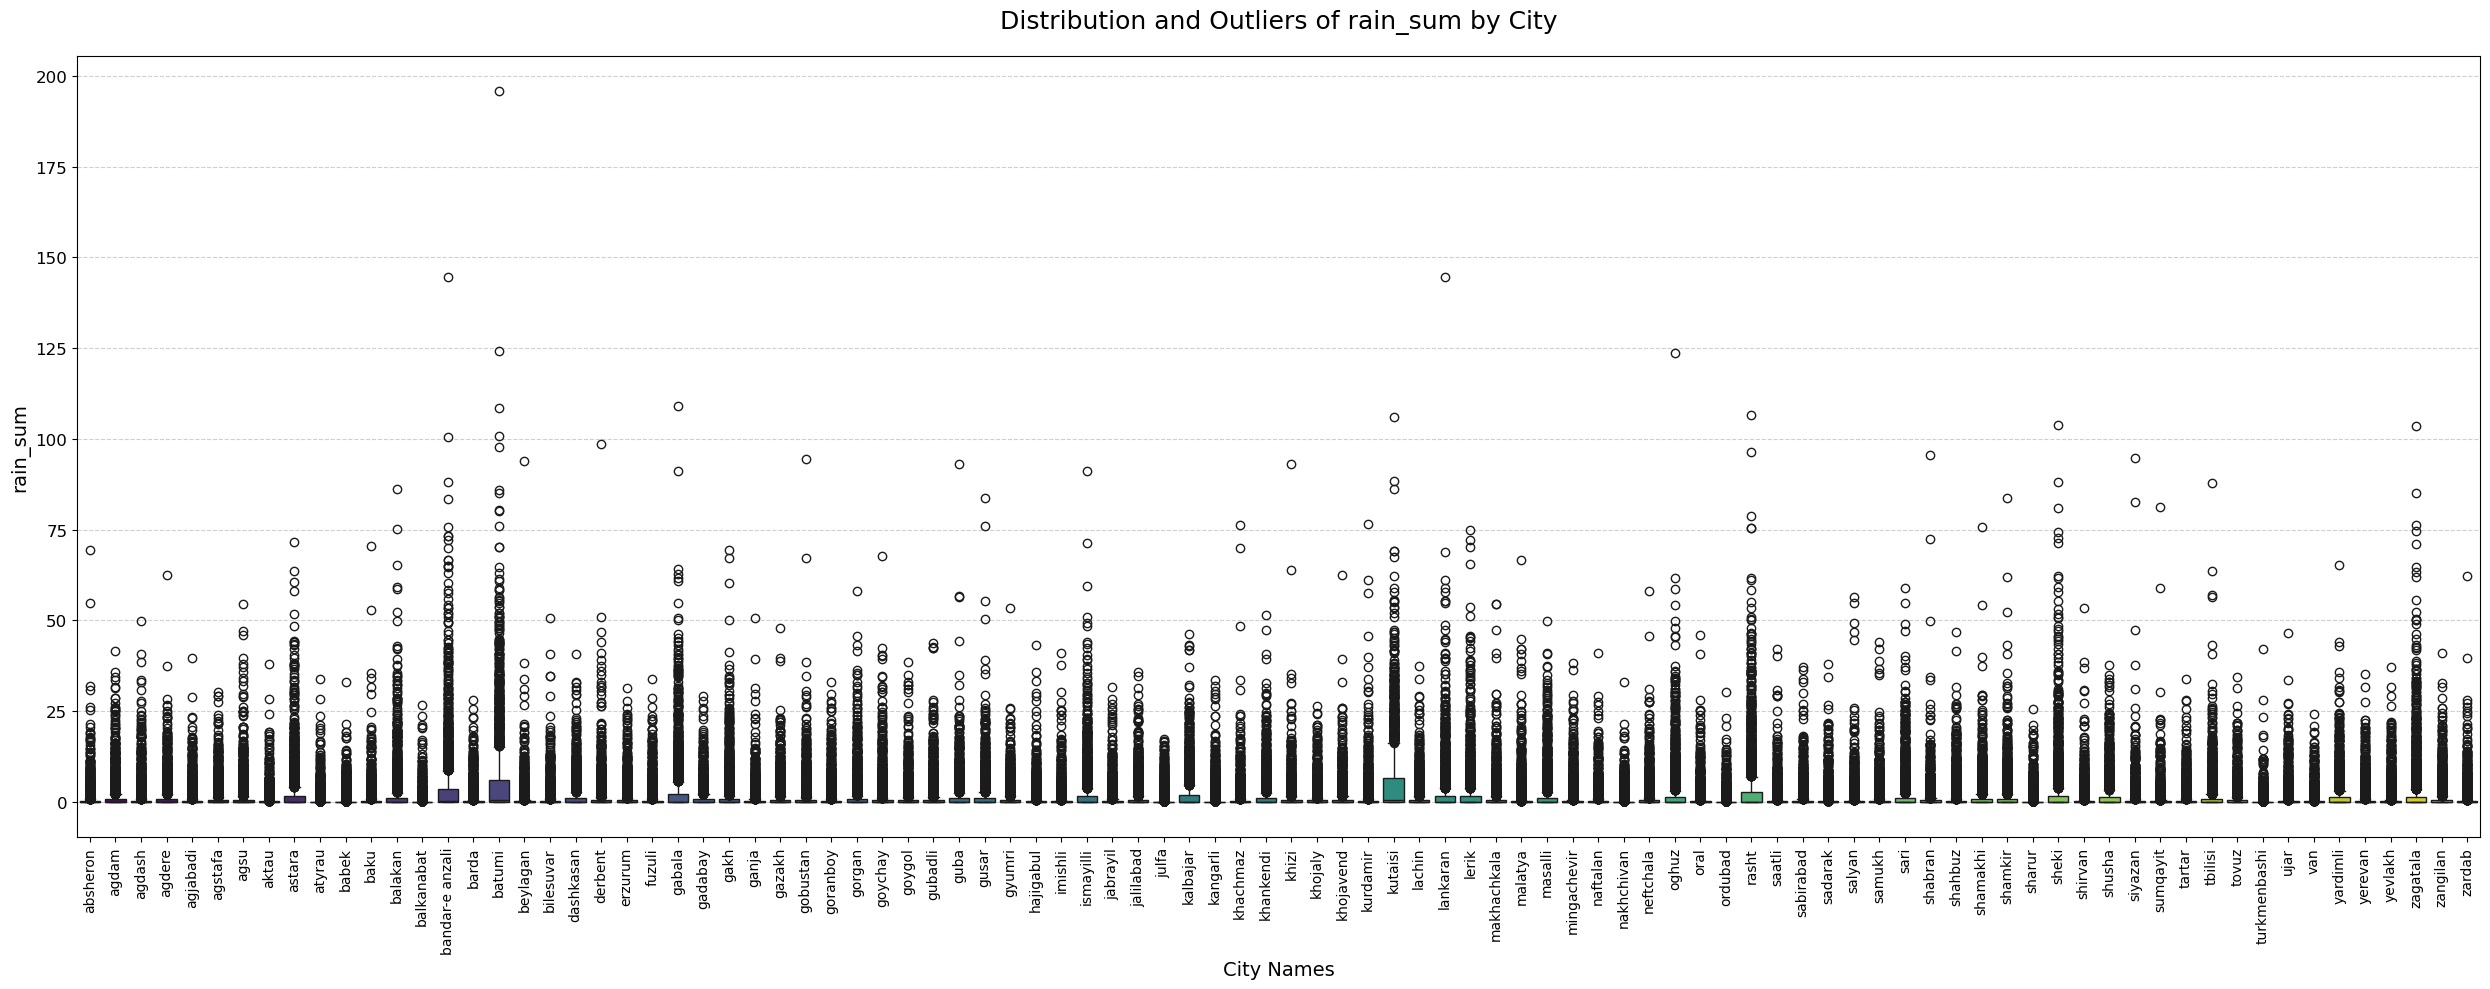


--- Outlier Report for: snowfall_sum ---
city
absheron     67
agdam       103
agdash       47
agdere      140
agjabadi     54
           ... 
yerevan     181
yevlakh      35
zagatala    138
zangilan    140
zardab       49
Name: snowfall_sum, Length: 94, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


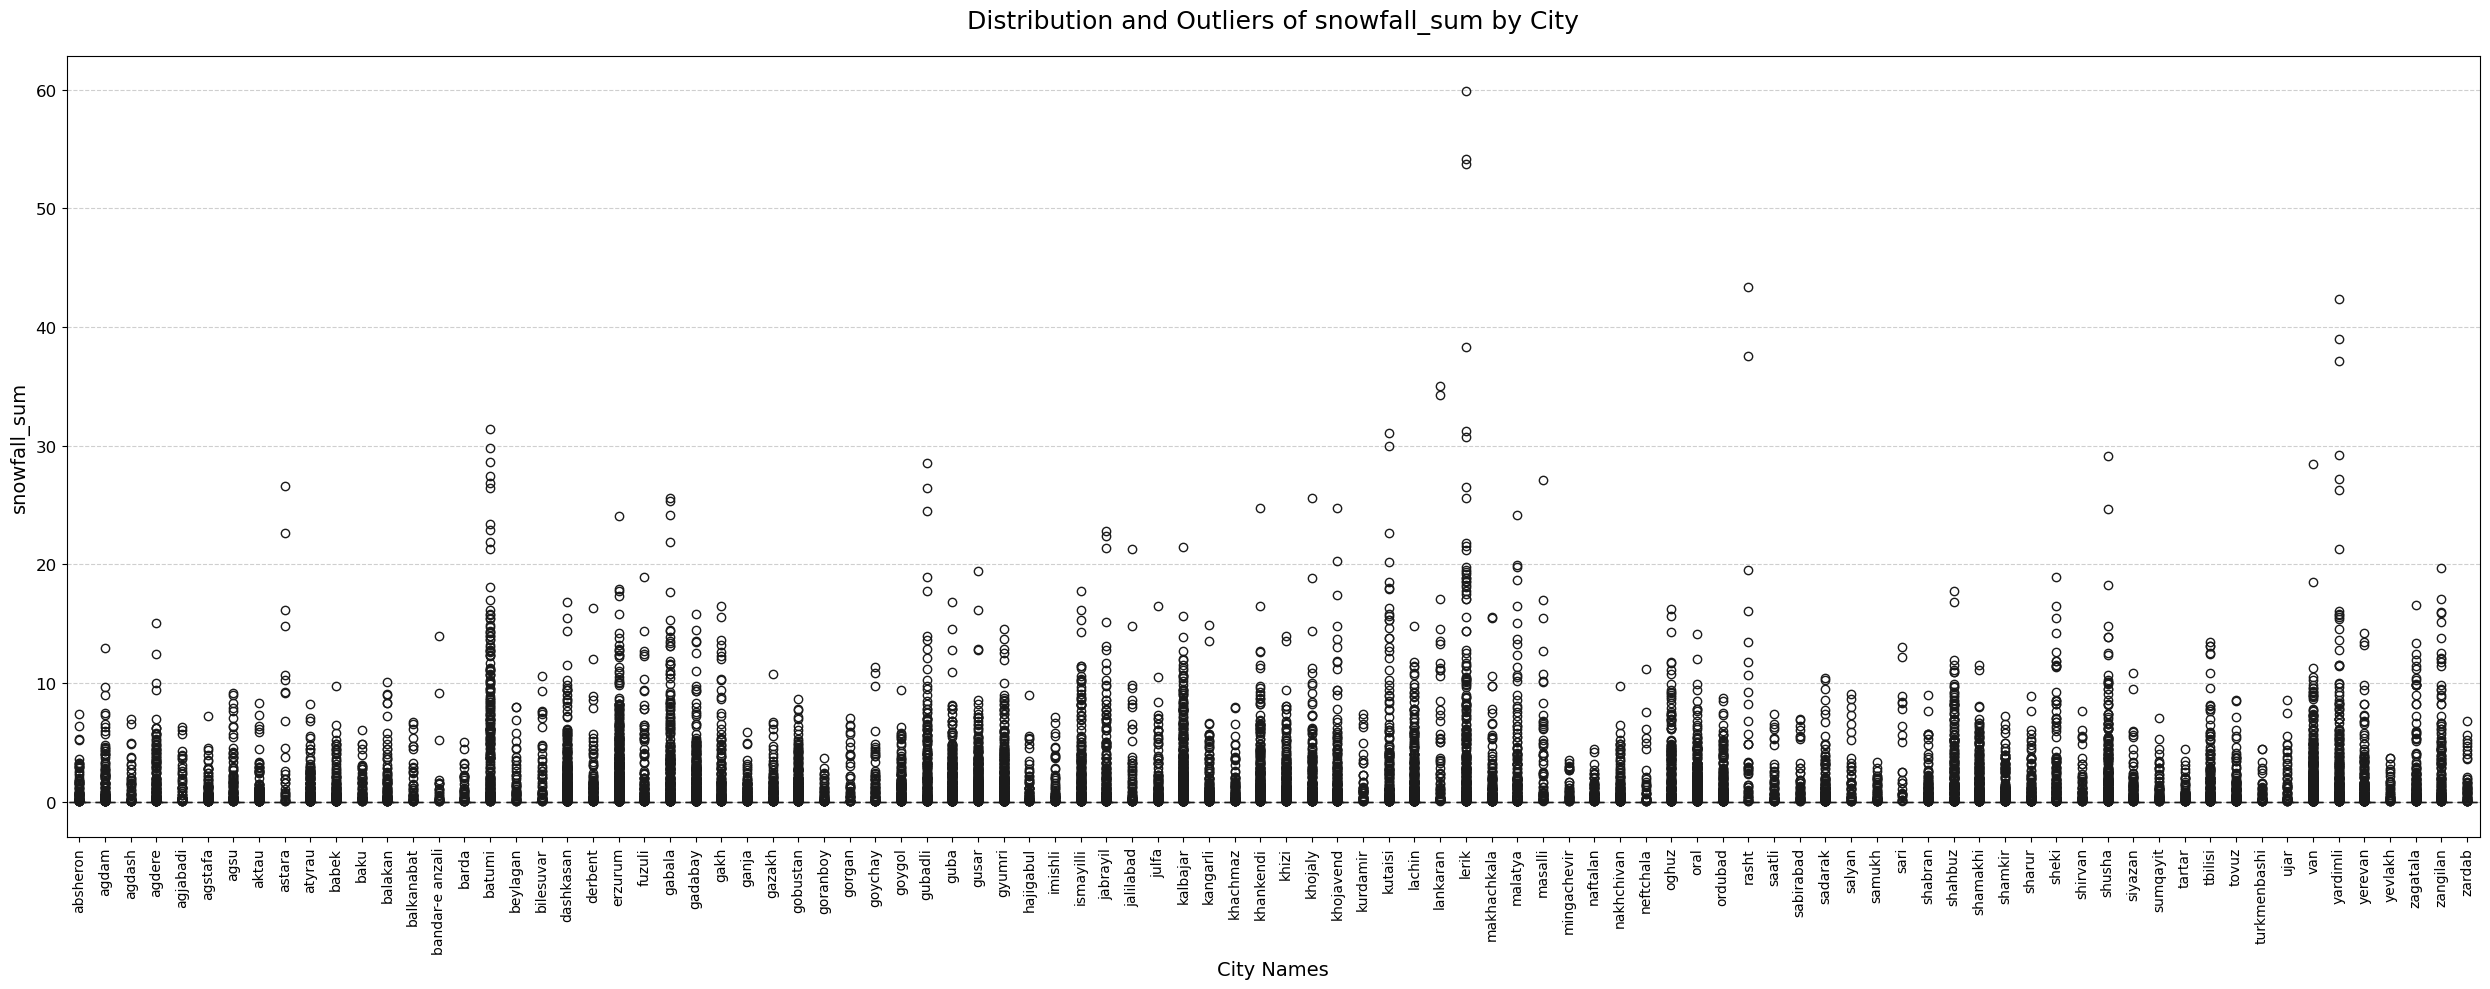


--- Outlier Report for: wind_speed_10m_max ---
city
absheron    25
agdam       41
agdash      54
agdere      62
agjabadi    40
            ..
yerevan      4
yevlakh     76
zagatala    90
zangilan    39
zardab      35
Name: wind_speed_10m_max, Length: 91, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


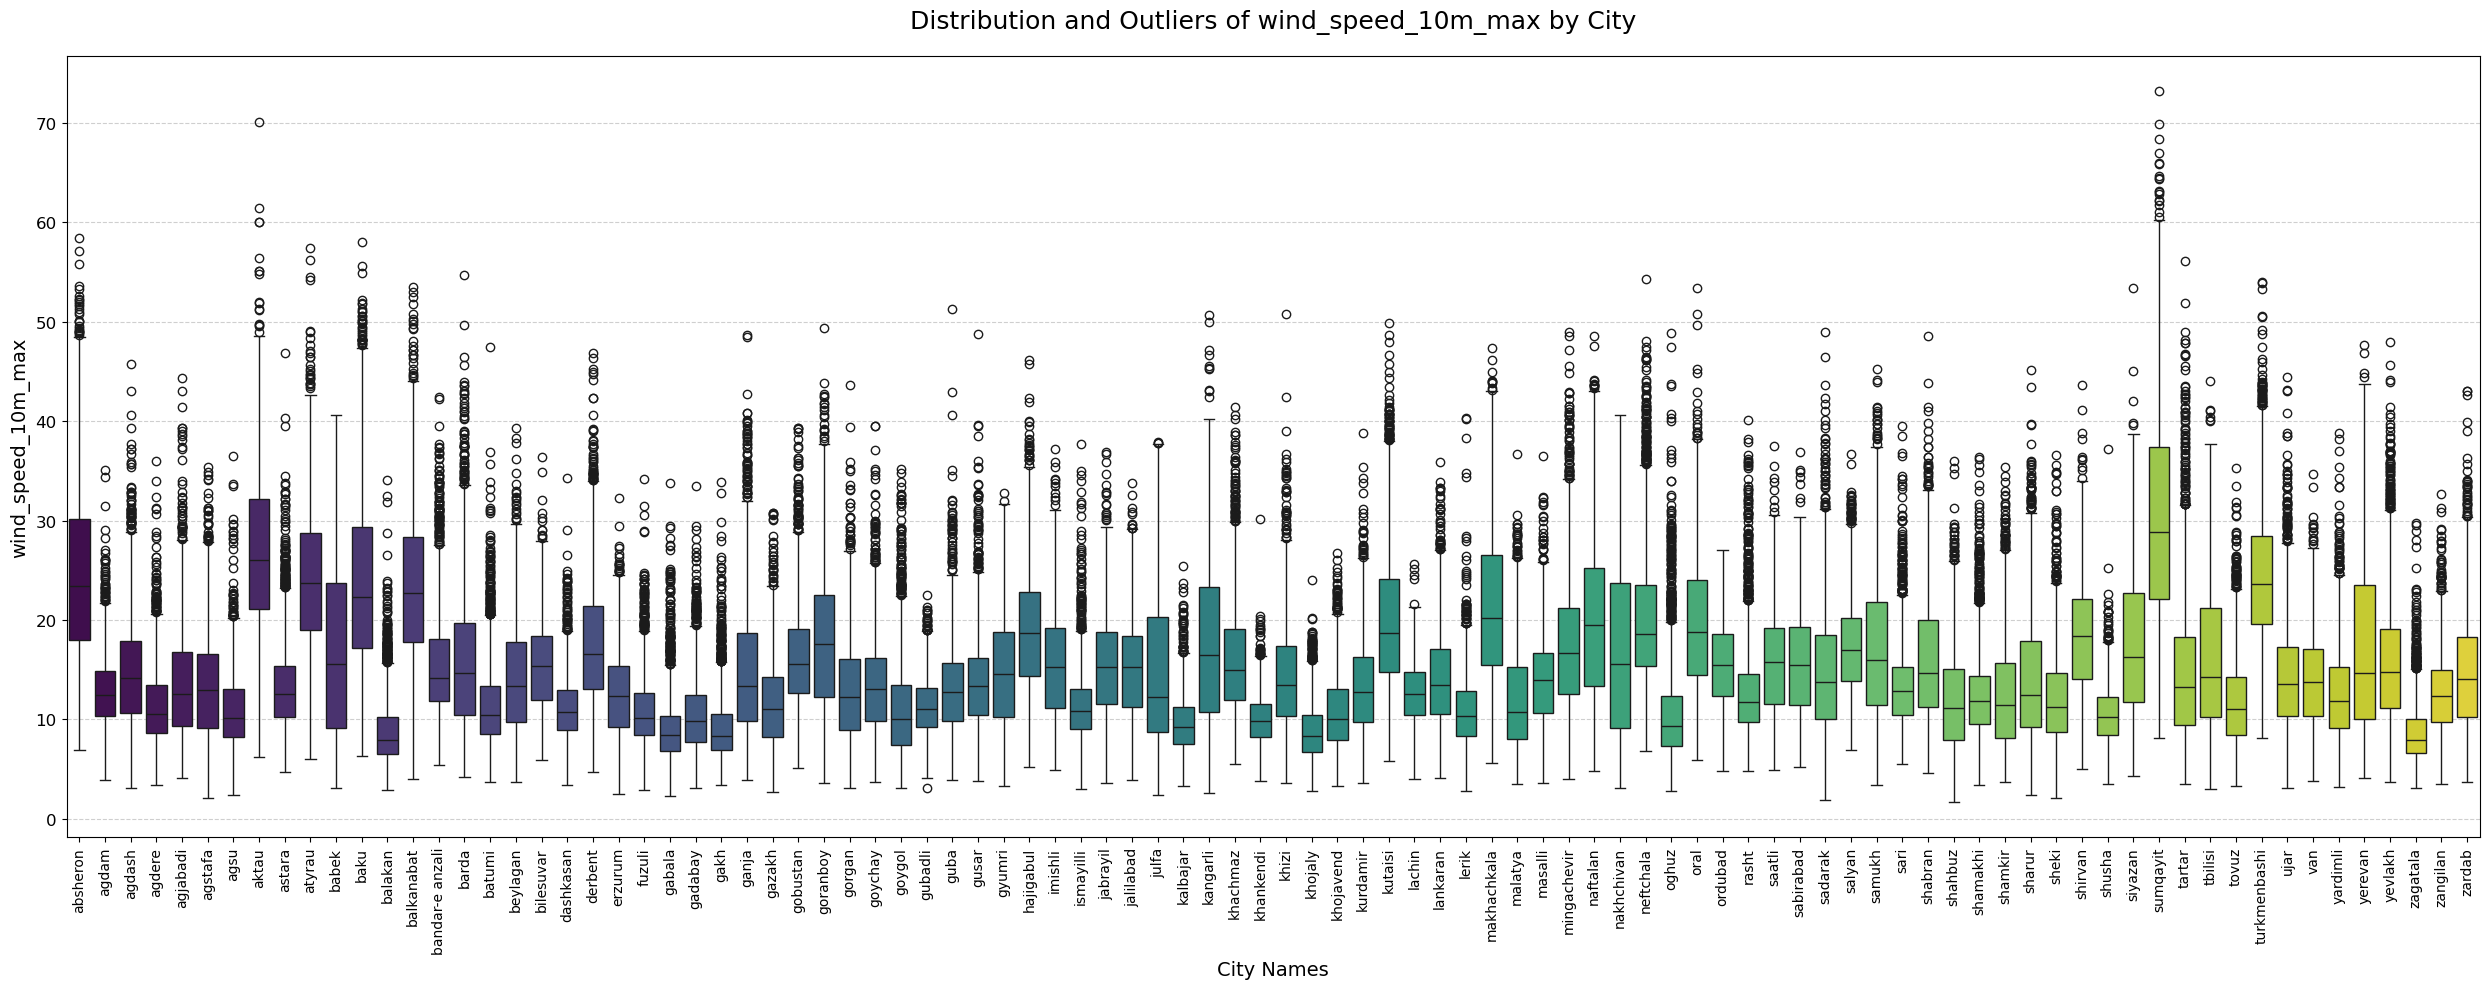


--- Outlier Report for: wind_gusts_10m_max ---
city
absheron     32
agdam        53
agdash       57
agdere       50
agjabadi     38
           ... 
yardimli     49
yevlakh      60
zagatala    126
zangilan     43
zardab       33
Name: wind_gusts_10m_max, Length: 90, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


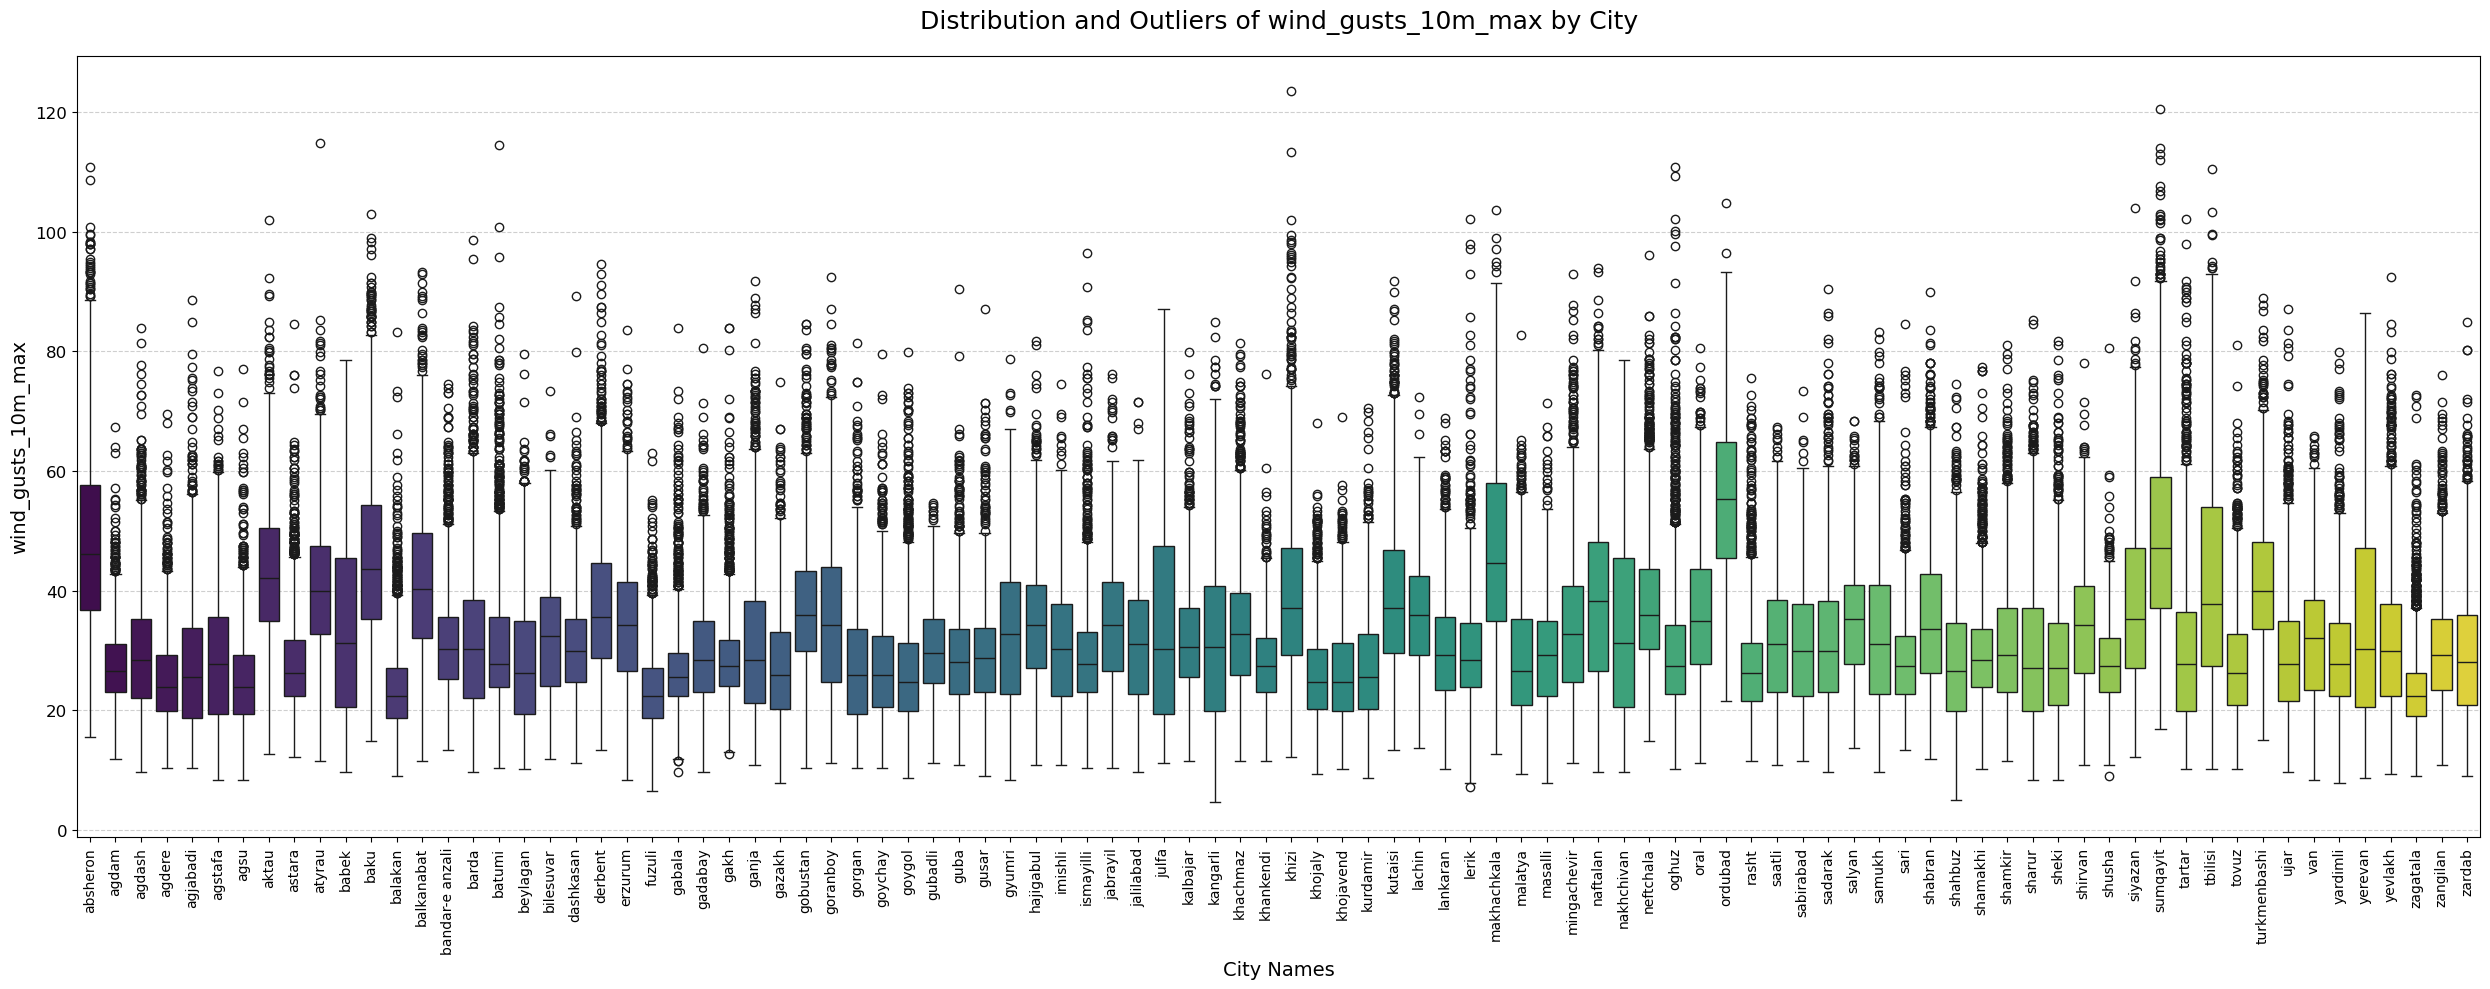


--- Outlier Report for: relative_humidity_2m_mean ---
city
absheron            9
agdam               4
agdere              1
agstafa             3
agsu                6
astara             14
baku                4
balakan             4
bandar-e anzali    45
batumi             33
dashkasan          10
derbent             7
gadabay            10
gakh                1
gazakh              5
gobustan            1
gorgan              1
goygol              1
guba                4
gubadli             3
gusar               4
gyumri             17
hajigabul           1
ismayilli           3
jalilabad           5
kalbajar            6
khachmaz            4
khankendi          13
khizi              11
khojaly             3
kutaisi             2
lachin              5
lankaran            4
lerik               2
makhachkala         5
masalli            11
neftchala           5
rasht              43
sari               28
shabran            17
shamakhi            8
sharur              1
sheki           

C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


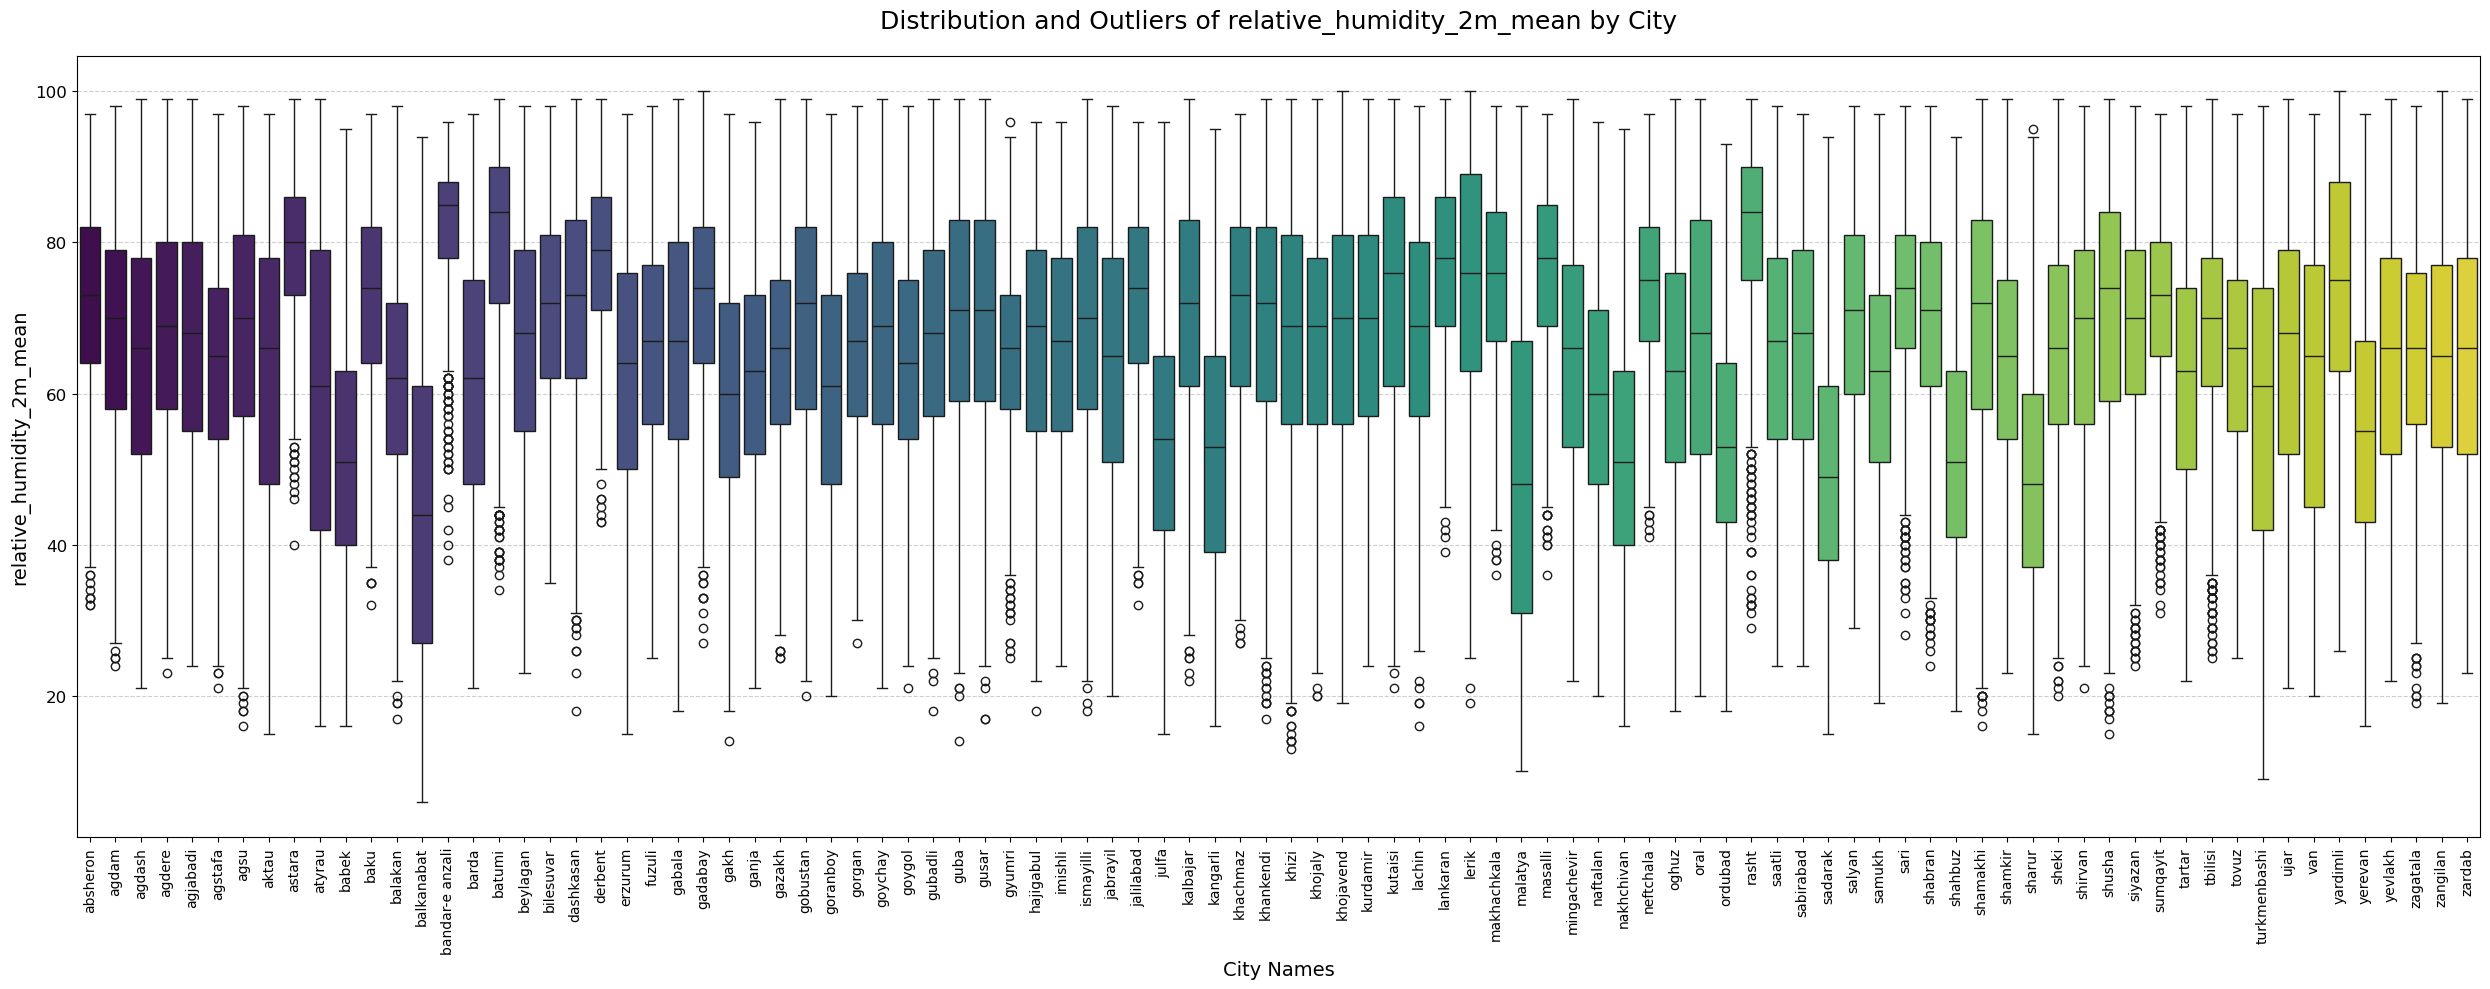


--- Outlier Report for: pressure_msl_mean ---
city
absheron     7
agdam        7
agdash       6
agdere      11
agjabadi     6
            ..
yerevan      3
yevlakh      6
zagatala    13
zangilan     8
zardab       6
Name: pressure_msl_mean, Length: 94, dtype: int64


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


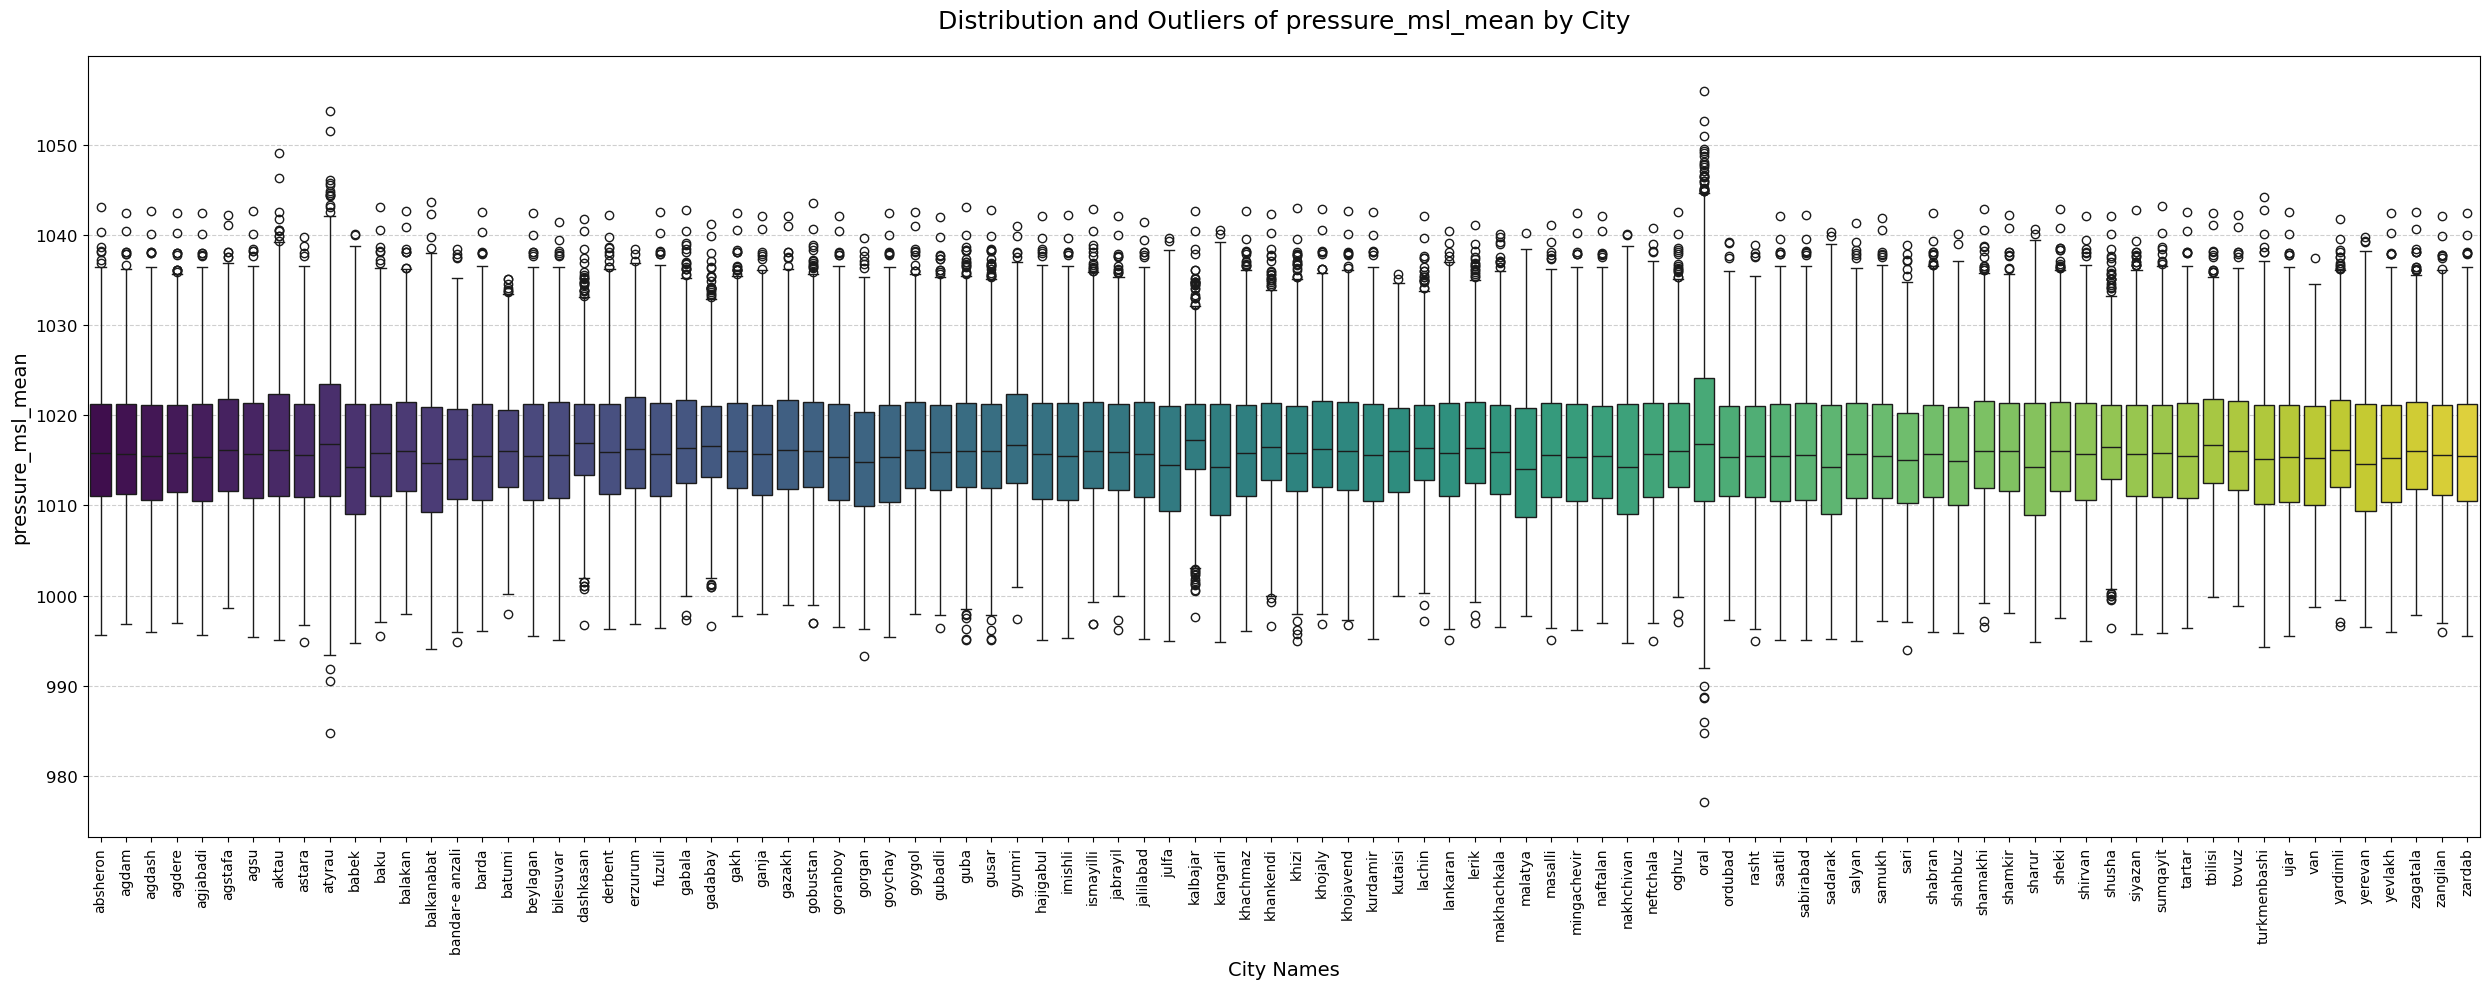


--- Outlier Report for: cloud_cover_mean ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


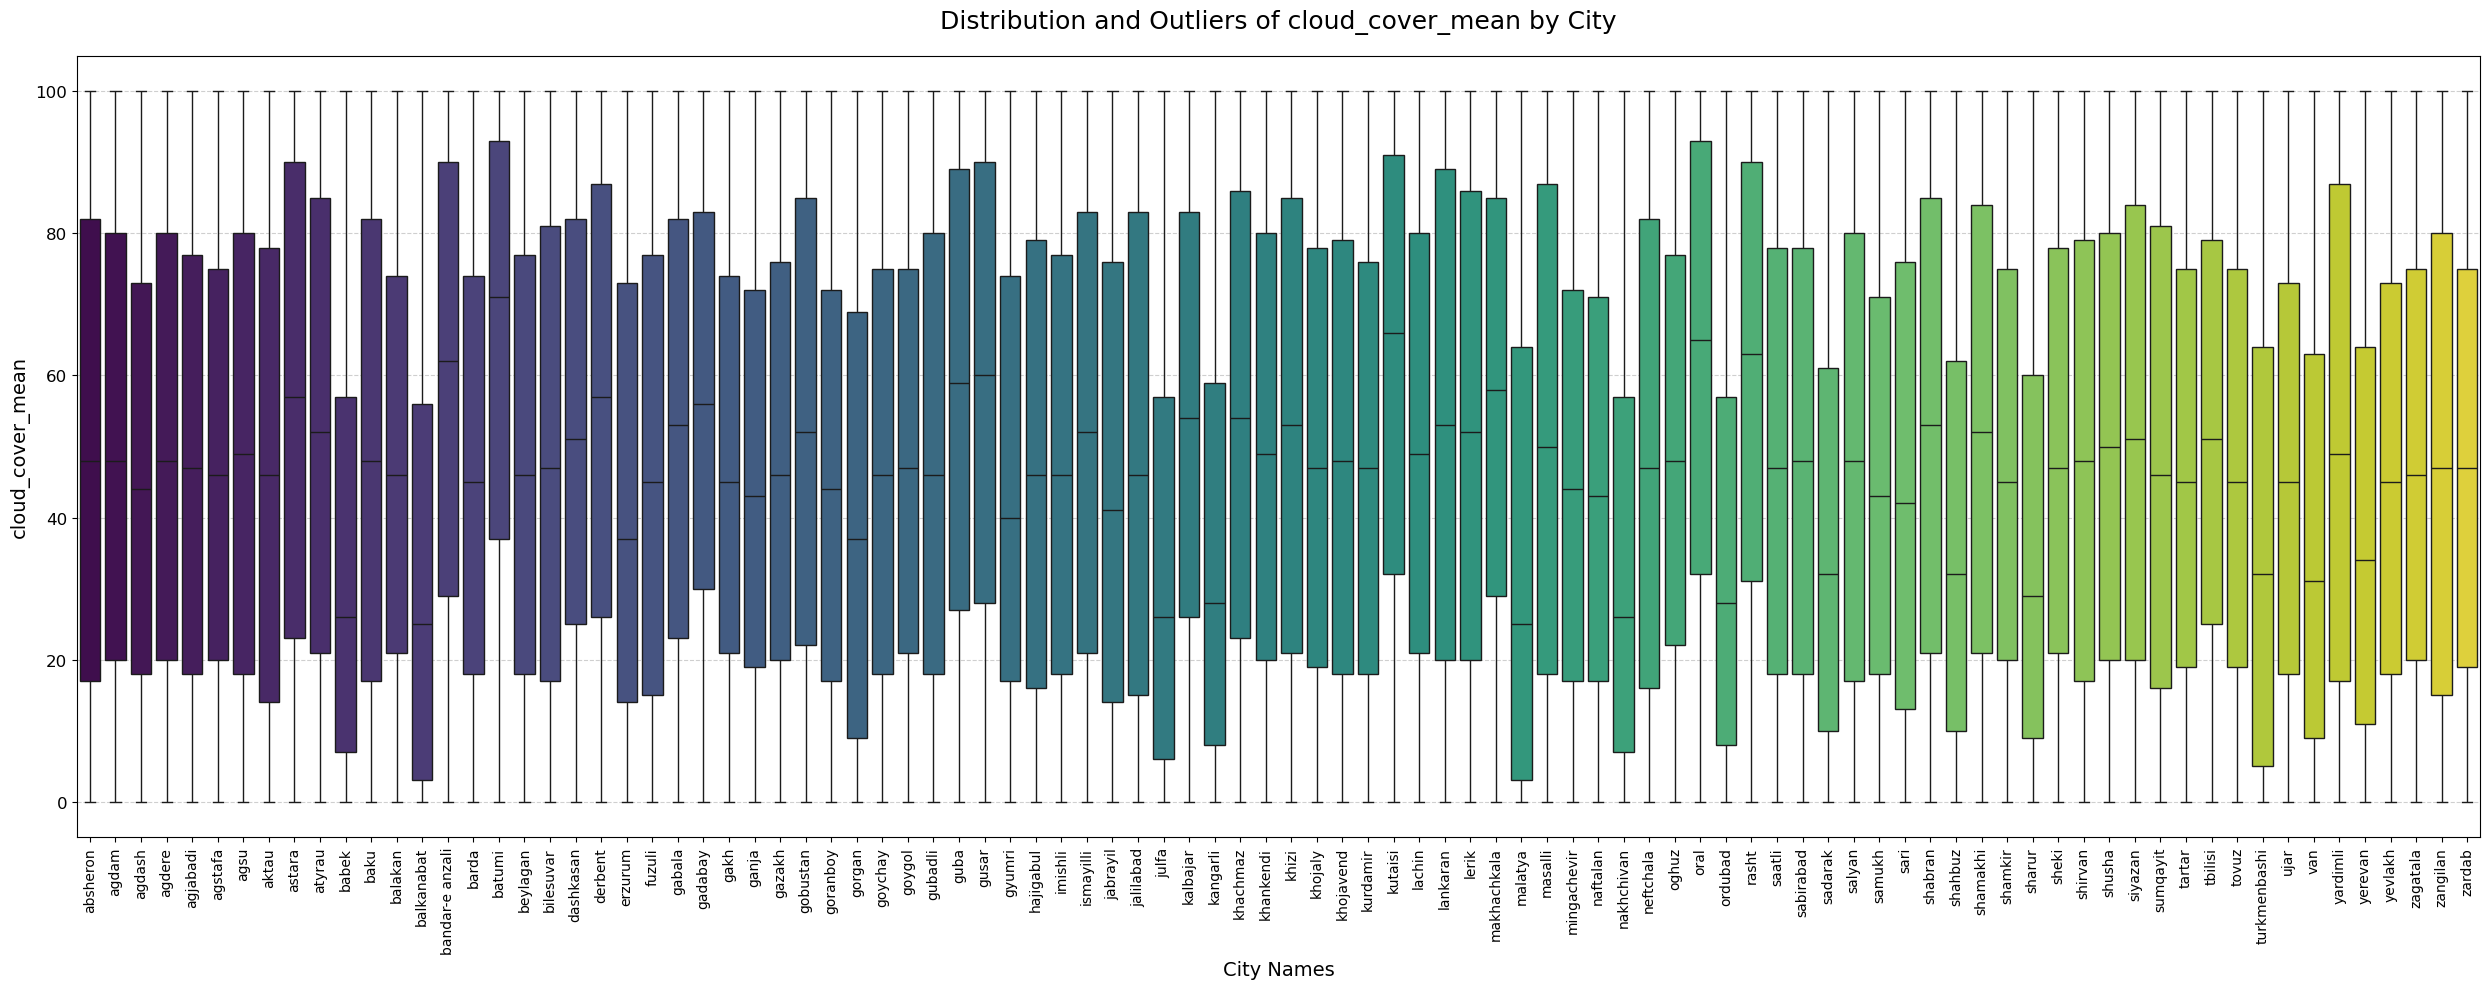


--- Outlier Report for: shortwave_radiation_sum ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


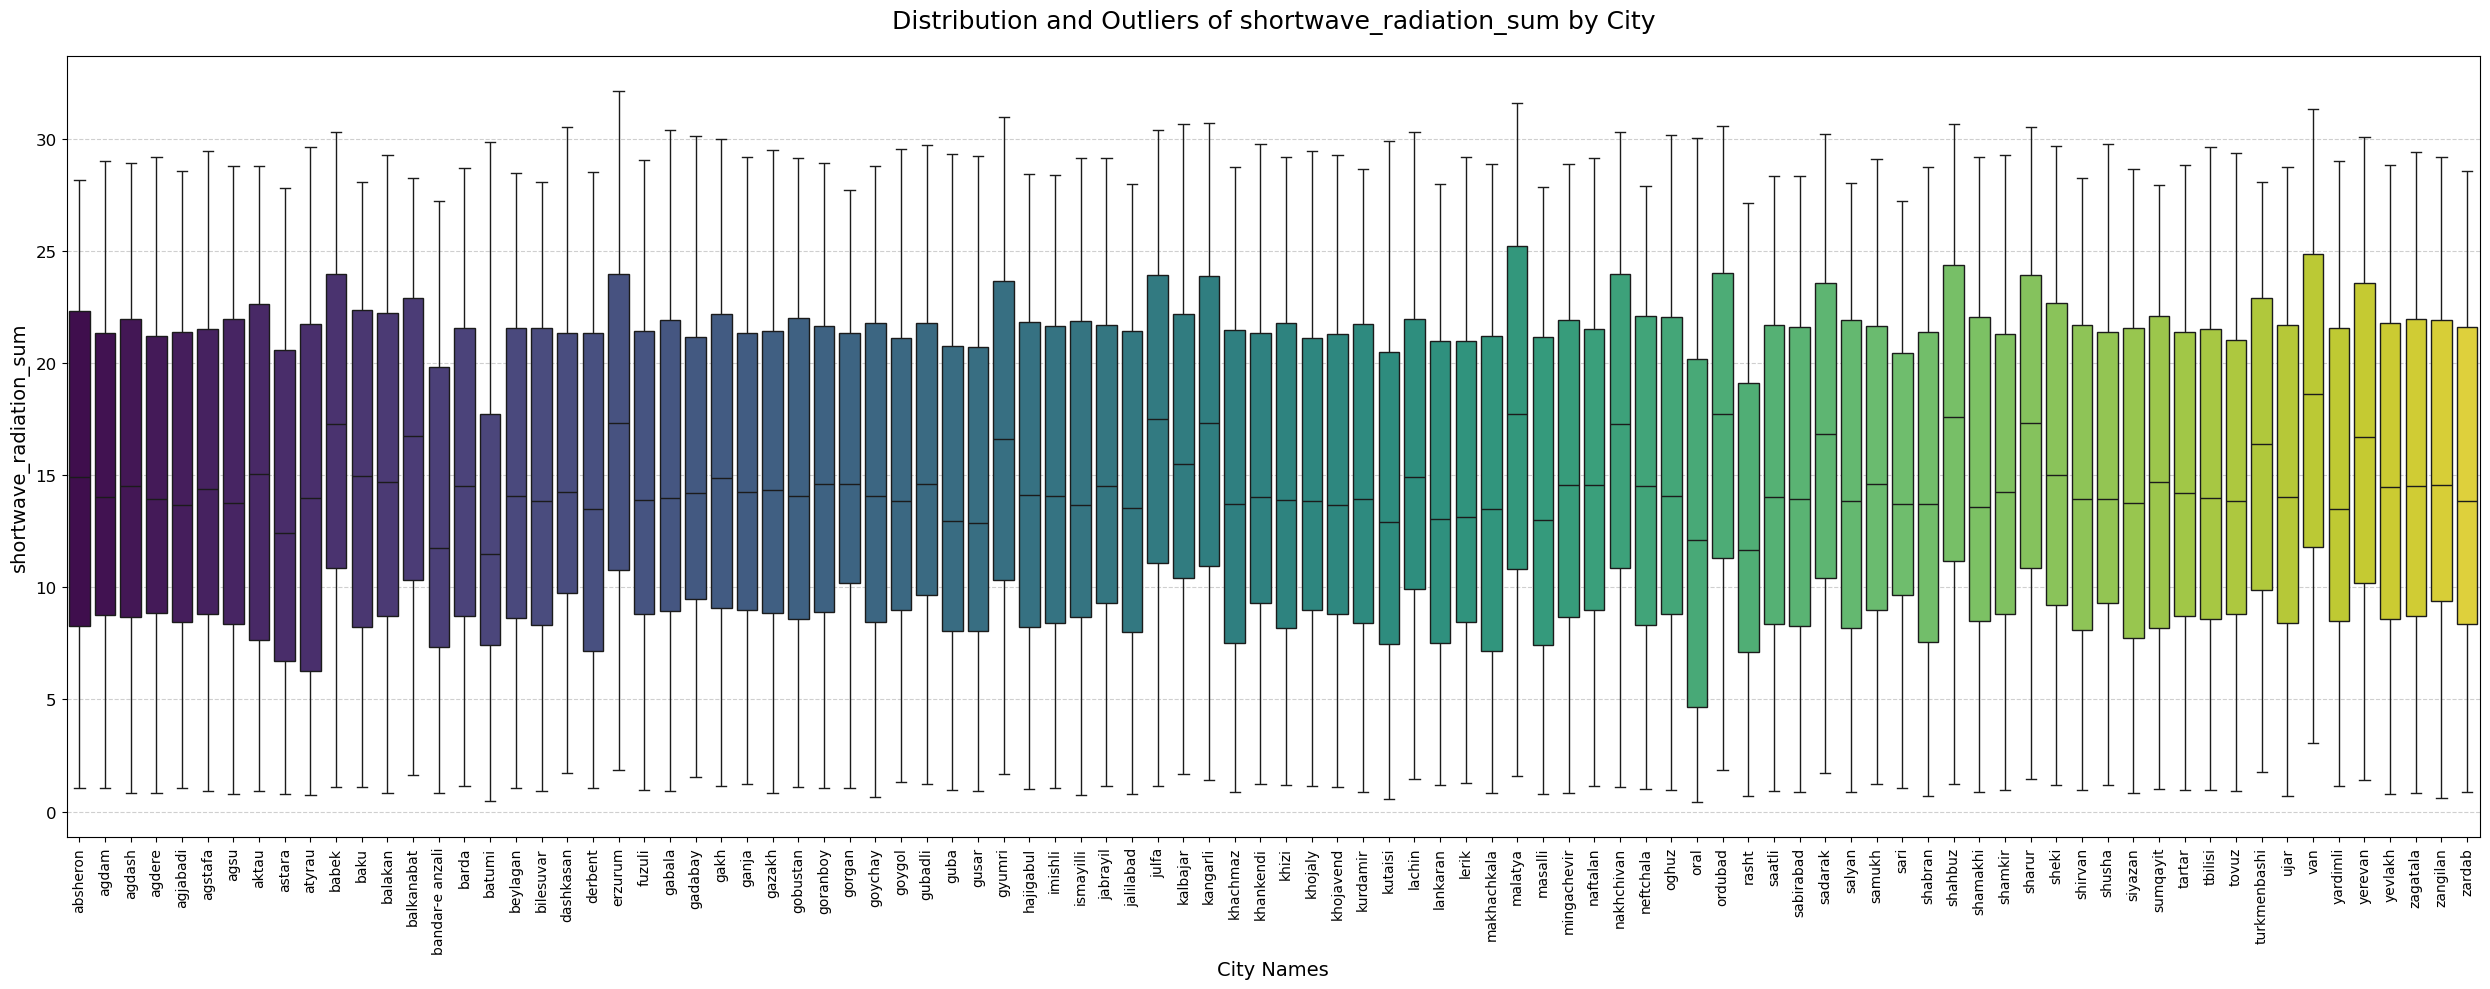


--- Outlier Report for: apparent_temperature_max ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


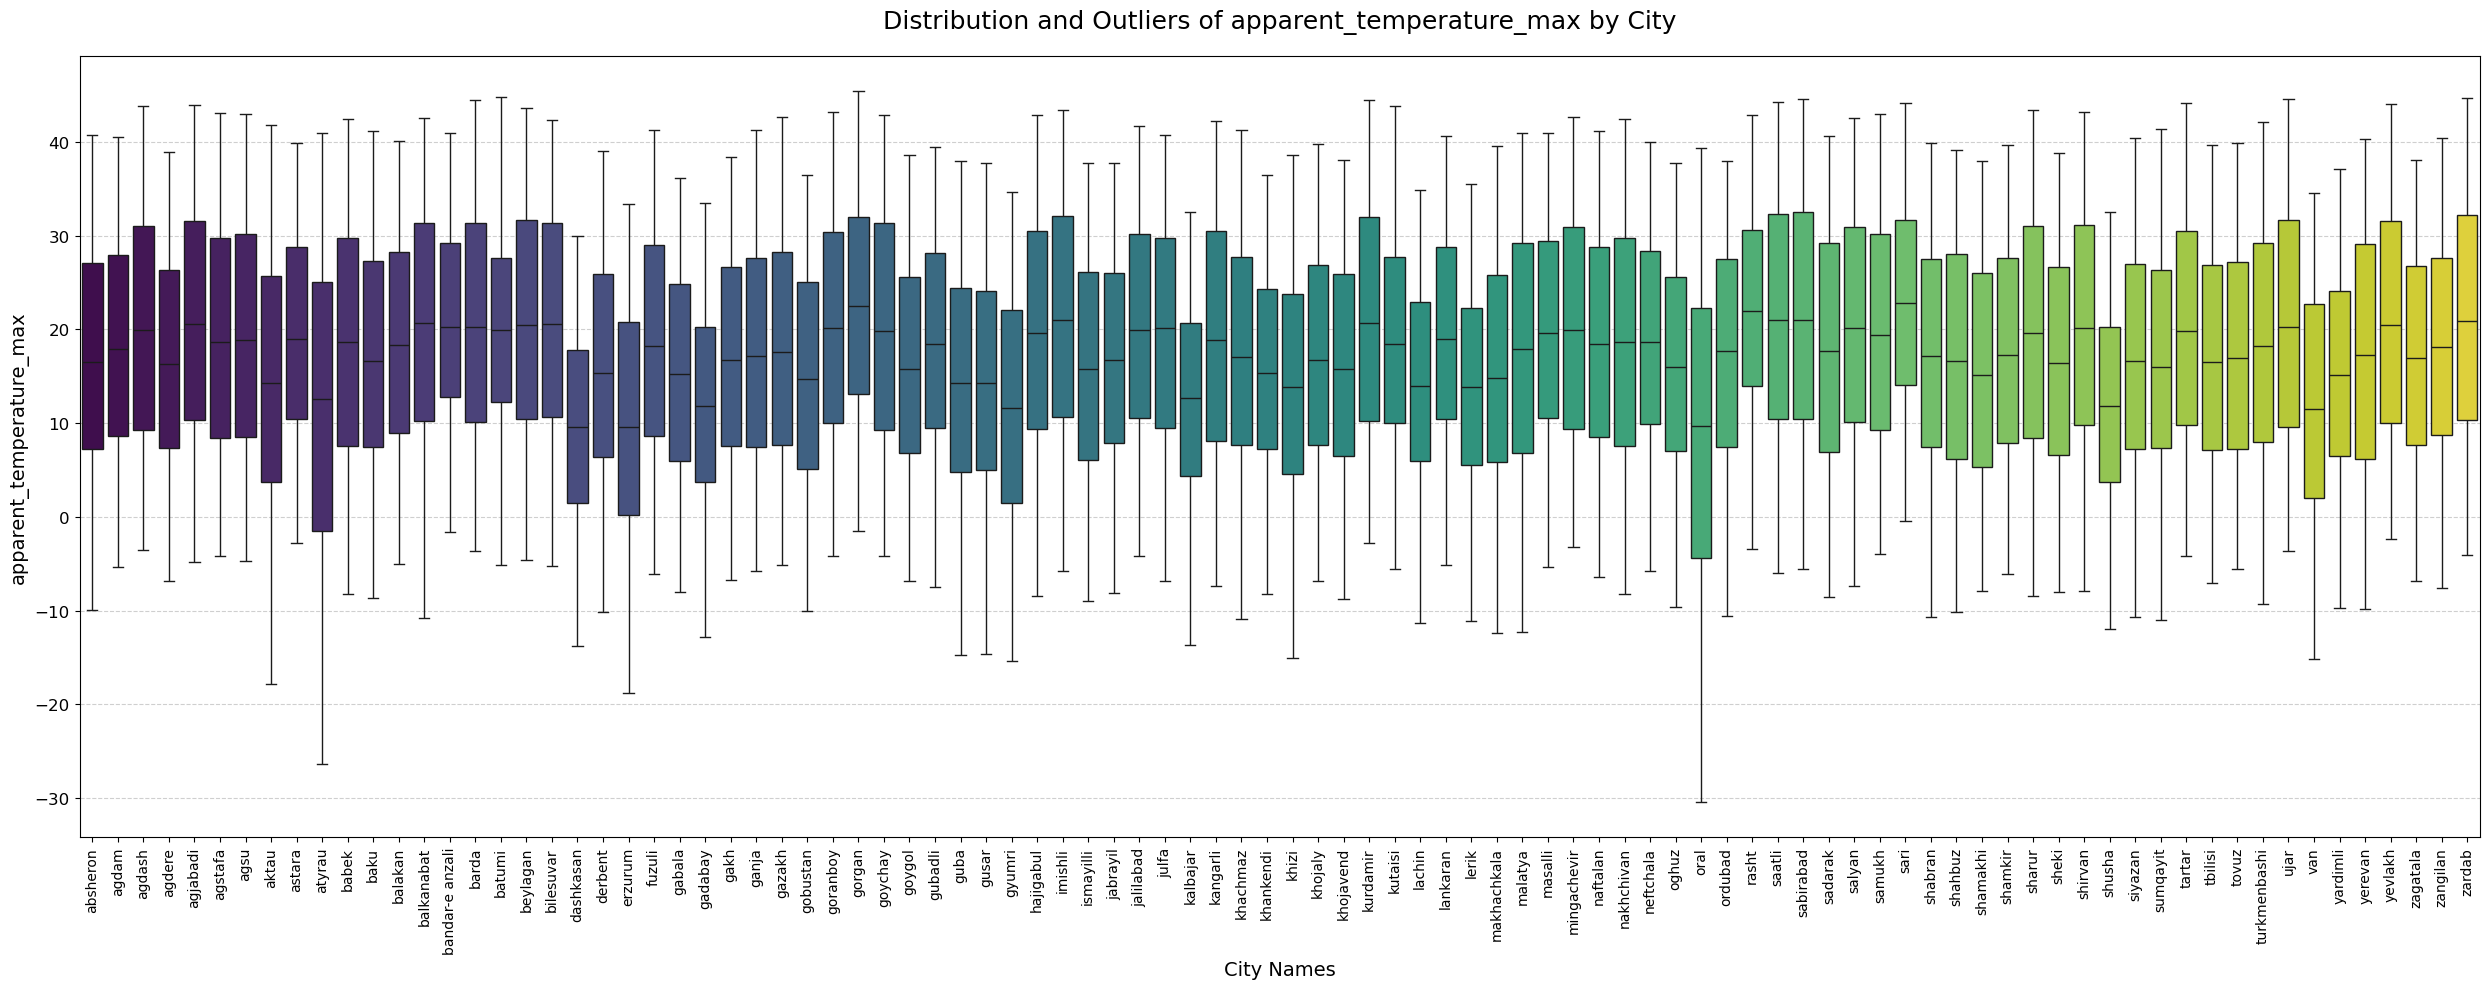


--- Outlier Report for: latitude ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


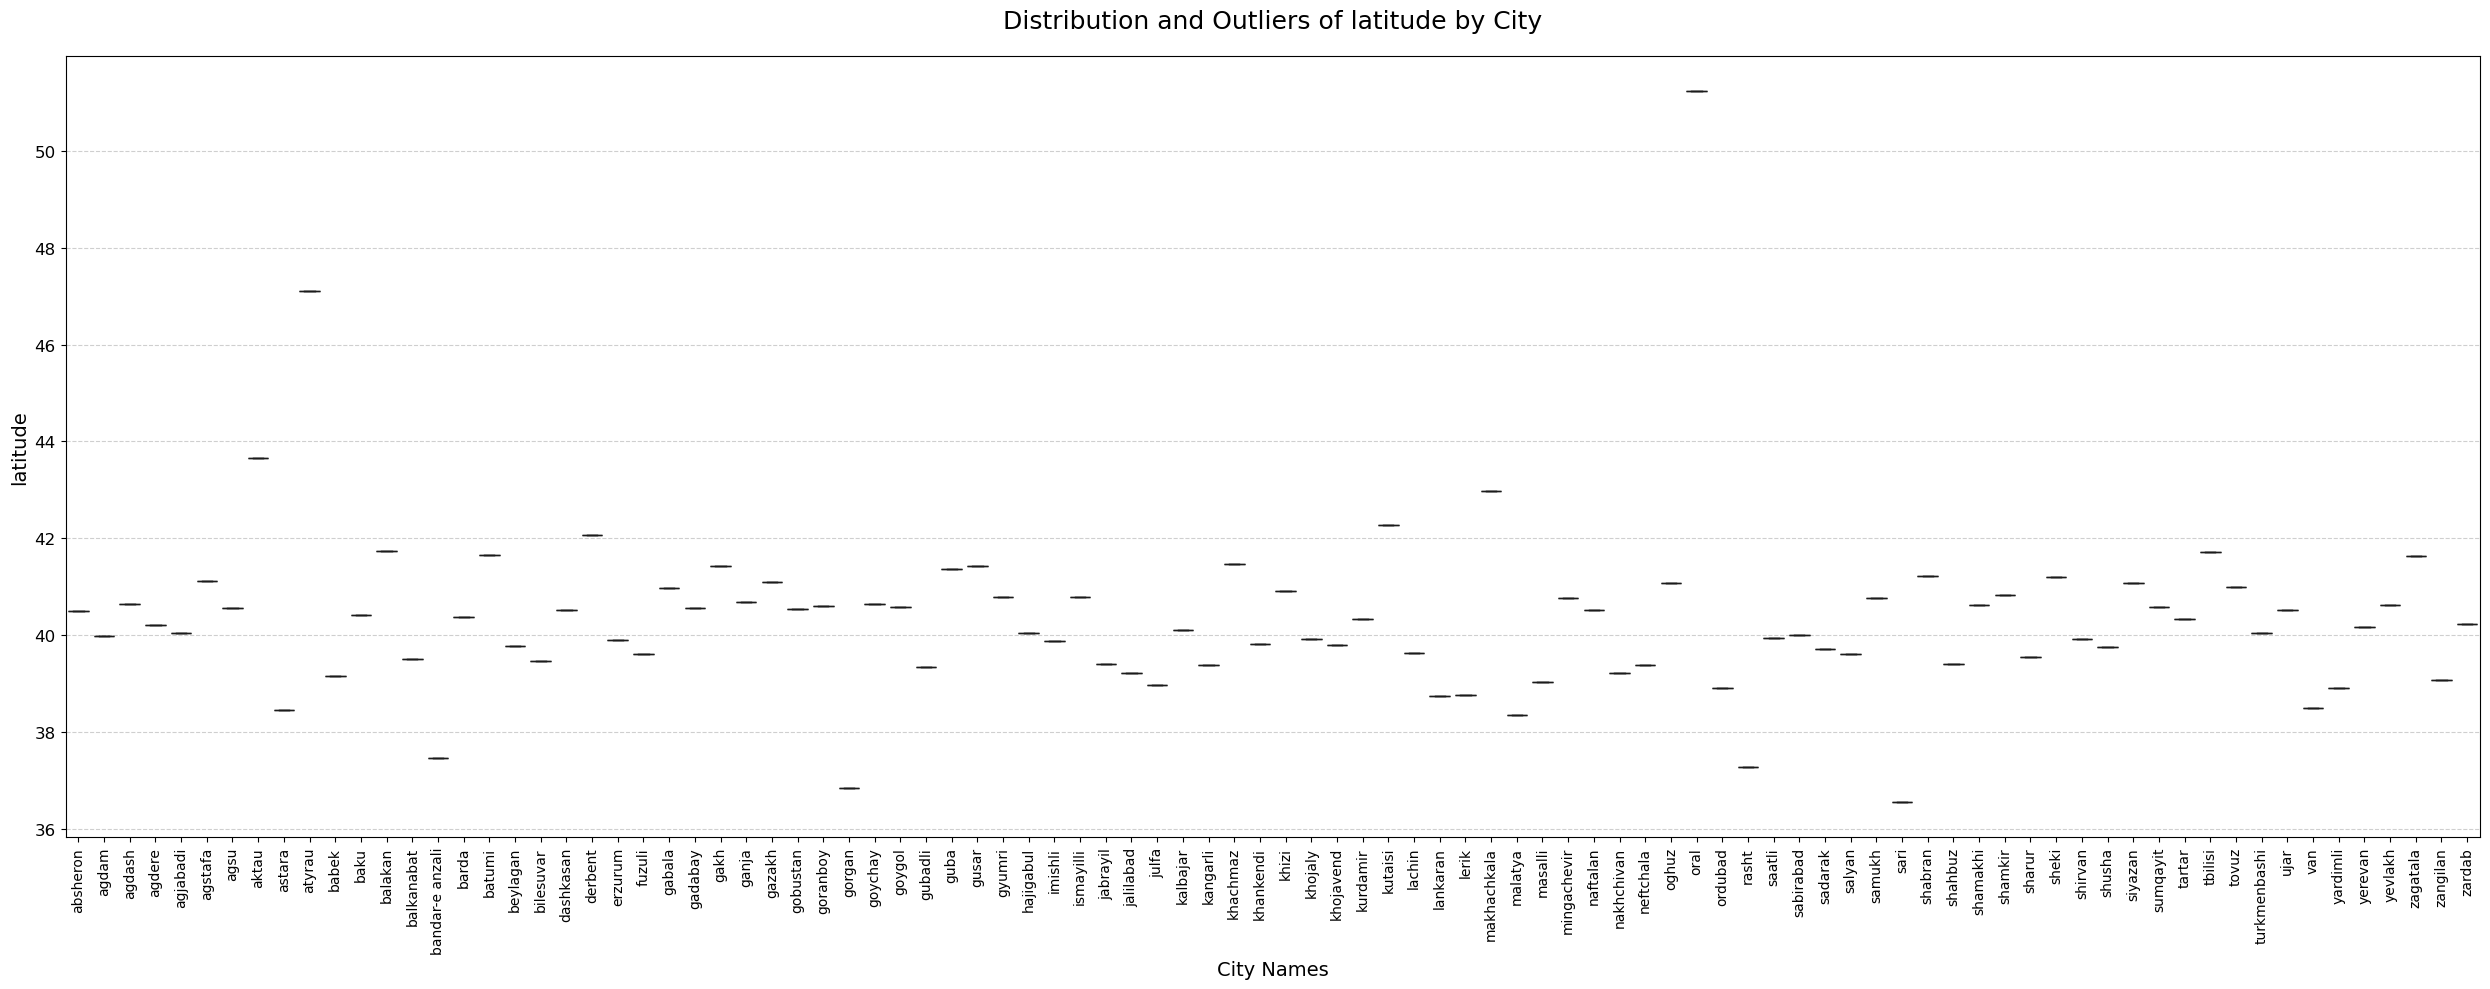


--- Outlier Report for: longitude ---
No outliers detected for this variable.


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_2616\3770063011.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y=col, data=df, palette="viridis")


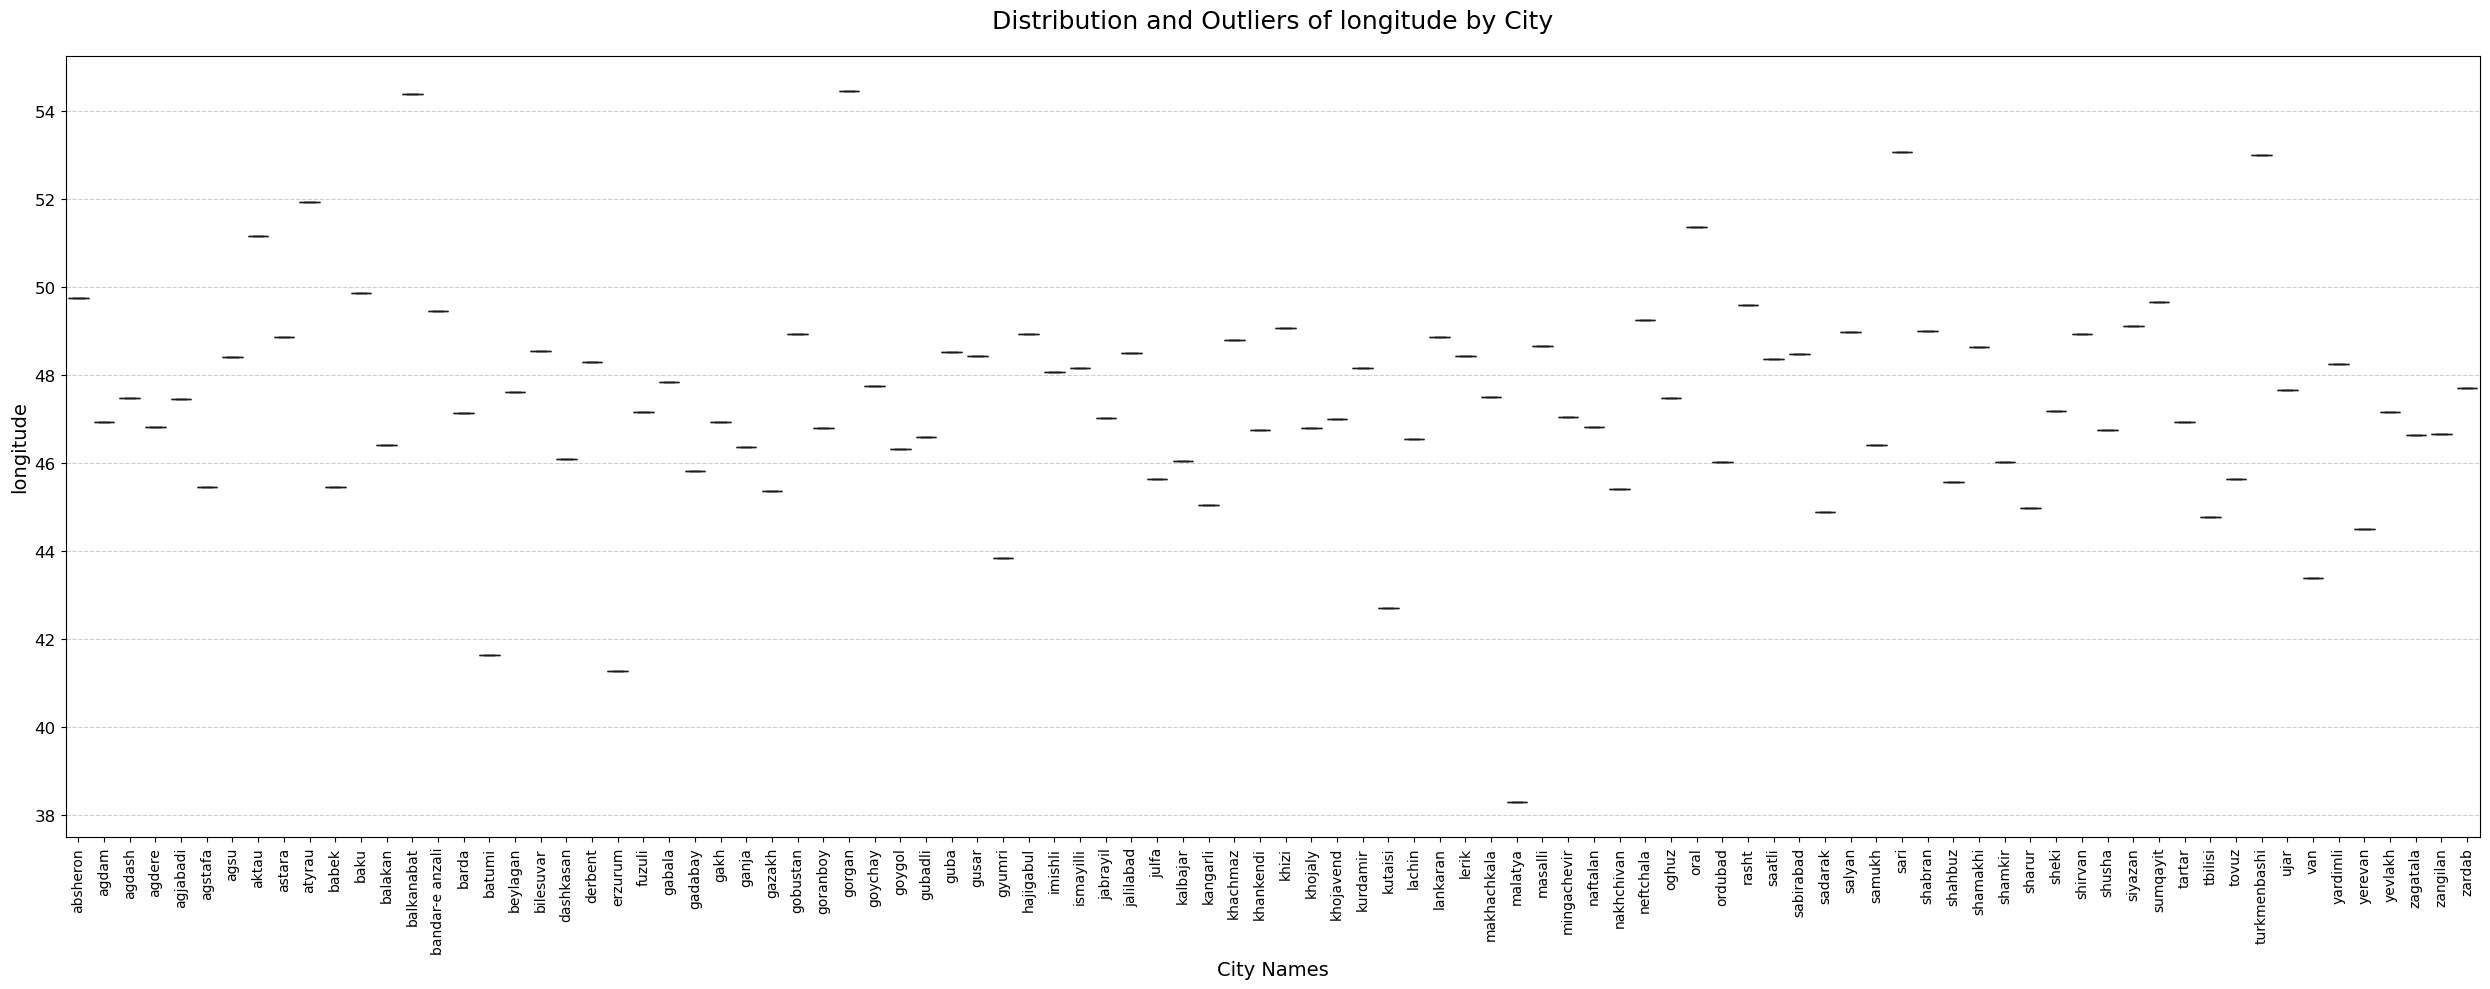

In [4]:
# 1. Select all numerical columns (excluding non-numeric fields)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude categorical numerical columns if necessary
cols_to_plot = [col for col in numeric_cols if col != 'weather_code']

# 2. Iterate through each column to detect outliers and create box plots
for col in cols_to_plot:
    print(f"\n--- Outlier Report for: {col} ---")
    
    # Calculate IQR and flag outliers for each city
    def count_outliers(group_data):
        q1 = group_data.quantile(0.25)
        q3 = group_data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        return ((group_data < lower_bound) | (group_data > upper_bound)).sum()

    # Get outlier counts per city
    city_outlier_counts = df.groupby('city')[col].apply(count_outliers)
    
    # Print outlier summary (only showing cities that have at least one outlier)
    significant_outliers = city_outlier_counts[city_outlier_counts > 0]
    if not significant_outliers.empty:
        print(significant_outliers)
    else:
        print("No outliers detected for this variable.")

    # 3. Create the Box Plot visualization
    # Set a large figure size to handle many cities
    plt.figure(figsize=(25, 10))
    
    # Generate box plot
    sns.boxplot(x='city', y=col, data=df, palette="viridis")
    
    # Rotate city names 90 degrees and adjust font for clarity
    plt.xticks(rotation=90, ha='center', fontsize=10)
    plt.yticks(fontsize=12)
    
    # Set titles and axis labels
    plt.title(f'Distribution and Outliers of {col} by City', fontsize=18, pad=20)
    plt.xlabel('City Names', fontsize=14)
    plt.ylabel(col, fontsize=14)
    
    # Add background grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Ensure all elements fit within the image area
    plt.tight_layout()
    
    # Display the plot
    plt.show()

1.3) Temporal gaps

City: absheron | Missing Dates: 2301
City: agdam | Missing Dates: 2301
City: agdash | Missing Dates: 2301
City: agdere | Missing Dates: 2301
City: agjabadi | Missing Dates: 2301
City: agstafa | Missing Dates: 2301
City: agsu | Missing Dates: 2301
City: aktau | Missing Dates: 2301
City: astara | Missing Dates: 2301
City: atyrau | Missing Dates: 2301
City: babek | Missing Dates: 2301
City: baku | Missing Dates: 2301
City: balakan | Missing Dates: 2301
City: balkanabat | Missing Dates: 2301
City: bandar-e anzali | Missing Dates: 1935
City: barda | Missing Dates: 2301
City: batumi | Missing Dates: 2301
City: beylagan | Missing Dates: 2301
City: bilesuvar | Missing Dates: 2301
City: dashkasan | Missing Dates: 2301
City: derbent | Missing Dates: 2301
City: erzurum | Missing Dates: 2301
City: fuzuli | Missing Dates: 2301
City: gabala | Missing Dates: 2301
City: gadabay | Missing Dates: 2301
City: gakh | Missing Dates: 2301
City: ganja | Missing Dates: 2301
City: gazakh | Missing Dates: 2301
C

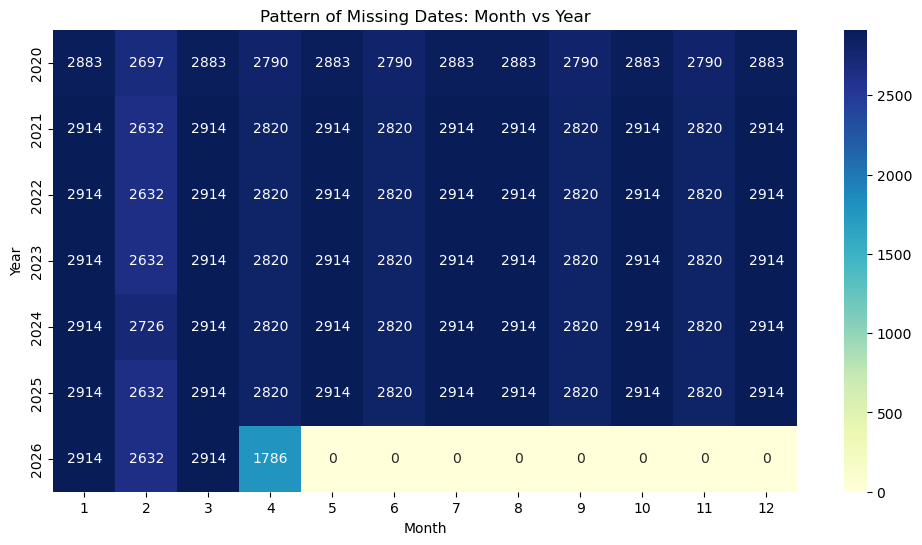

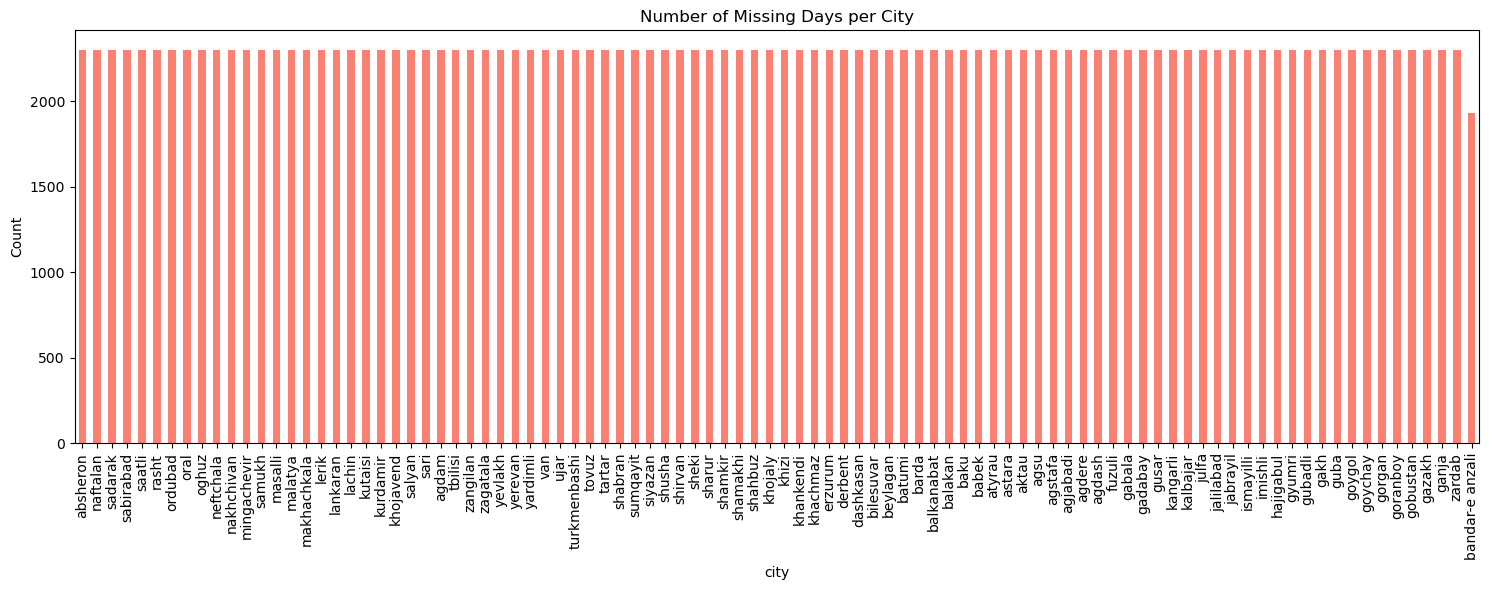

In [5]:
all_missing_dates = []

for city, group in df.groupby('city'):
    # Sort data by time to ensure chronological order
    group = group.sort_values('time')
    
    # Define the full expected date range for this city
    start_date = group['time'].min()
    end_date = group['time'].max()
    full_range = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # Identify dates that are in the full range but missing from the dataframe
    missing_dates = full_range.difference(group['time'])
    
    if len(missing_dates) > 0:
        print(f"City: {city} | Missing Dates: {len(missing_dates)}")
        # Collect missing dates into a list for pattern analysis
        for d in missing_dates:
            all_missing_dates.append({'city': city, 'date': d})
    else:
        print(f"City: {city} | Timeline is complete.")

# --- Pattern Analysis ---
if all_missing_dates:
    # Create a dataframe of missing dates
    missing_df = pd.DataFrame(all_missing_dates)
    missing_df['year'] = missing_df['date'].dt.year
    missing_df['month'] = missing_df['date'].dt.month
    
    # 1. Visualize Patterns by Year and Month
    plt.figure(figsize=(12, 6))
    pattern_pivot = missing_df.groupby(['year', 'month']).size().unstack(fill_value=0)
    
    sns.heatmap(pattern_pivot, annot=True, fmt="d", cmap="YlGnBu")
    plt.title('Pattern of Missing Dates: Month vs Year')
    plt.xlabel('Month')
    plt.ylabel('Year')
    plt.show()

    # 2. Visualize Gaps by City
    plt.figure(figsize=(15, 6))
    city_gaps = missing_df.groupby('city').size().sort_values(ascending=False)
    city_gaps.plot(kind='bar', color='salmon')
    plt.title('Number of Missing Days per City')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("No missing dates found across all cities.")

1.4) Consistency

In [7]:
import pandas as pd
import os

# 1. Directory path
folder_path = os.path.join('..', 'data', 'raw')

# 2. List ONLY files that contain 'forecast' in the name and end with '.csv'
all_files = [
    f for f in os.listdir(folder_path) 
    if f.endswith('.csv') and 'forecast' in f.lower()
]

print(f"Detected {len(all_files)} forecast files. Starting the merging process...")

# 3. Create a list to store each individual DataFrame
data_frames = []

for filename in all_files:
    file_path = os.path.join(folder_path, filename)
    
    # Read the CSV file
    temp_df = pd.read_csv(file_path)
    
    # Extract the city name from the filename for identification
    # Example: 'baku_forecast.csv' -> 'baku'
    city_name = filename.lower().replace('_forecast.csv', '').replace('.csv', '')
    temp_df['city'] = city_name
    
    data_frames.append(temp_df)

# 4. Concatenate all DataFrames into one
if data_frames:
    df_forecast = pd.concat(data_frames, ignore_index=True)

    # 5. Save the combined dataset
    output_filename = 'all_94_cities_forecast_combined.csv'
    output_path = os.path.join(folder_path, output_filename)
    
    # Write the file to the path
    df_forecast.to_csv(output_path, index=False)
    
    print(f"Success! Data merged into '{output_filename}'.")
    print(f"Total rows in merged dataset: {len(df_forecast)}")
else:
    print("No forecast CSV files found. Please check your folder path and filenames.")

# --- 4. Consistency: Historical (df) vs Forecast (df_forecast) ---
print("\n--- 4. Consistency Assessment ---")

# Ensure time columns are in datetime format for both dataframes
df['time'] = pd.to_datetime(df['time'])
df_forecast['time'] = pd.to_datetime(df_forecast['time'])

# Merge dataframes on 'time' and 'city' to find overlapping records
# suffixes adds '_hist' and '_fore' to identical column names
merged_df = pd.merge(
    df, 
    df_forecast, 
    on=['time', 'city'], 
    suffixes=('_hist', '_fore')
)

if not merged_df.empty:
    # 1. Calculate Absolute Difference for Mean Temperature
    # You can change the column name if yours is different
    merged_df['temp_diff'] = (merged_df['temperature_2m_mean_hist'] - merged_df['temperature_2m_mean_fore']).abs()

    # Define a threshold for discrepancy (e.g., more than 2 degrees)
    threshold = 2.0
    discrepancies = merged_df[merged_df['temp_diff'] > threshold]

    print(f"Total overlapping records: {len(merged_df)}")
    print(f"Records with >{threshold} degree difference: {len(discrepancies)}")

    # 2. Visualization: Scatter Plot to check agreement
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=merged_df, 
        x='temperature_2m_mean_hist', 
        y='temperature_2m_mean_fore', 
        alpha=0.4,
        color='blue'
    )
    
    # Draw a 45-degree line (Perfect Agreement line)
    max_val = max(merged_df['temperature_2m_mean_hist'].max(), merged_df['temperature_2m_mean_fore'].max())
    min_val = min(merged_df['temperature_2m_mean_hist'].min(), merged_df['temperature_2m_mean_fore'].min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement')

    plt.title('Consistency Check: Historical vs Forecast Mean Temp', fontsize=15)
    plt.xlabel('Historical Temperature (Celsius)')
    plt.ylabel('Forecast Temperature (Celsius)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Visualization: Difference distribution per city
    plt.figure(figsize=(25, 10))
    sns.boxplot(x='city', y='temp_diff', data=merged_df, palette='magma')
    plt.xticks(rotation=90, fontsize=10)
    plt.title('Temperature Discrepancy Distribution per City', fontsize=16)
    plt.ylabel('Absolute Difference |Hist - Fore|')
    plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
    plt.tight_layout()
    plt.show()

else:
    print("No overlapping date ranges found between historical and forecast data.")

Detected 94 forecast files. Starting the merging process...
Success! Data merged into 'all_94_cities_forecast_combined.csv'.
Total rows in merged dataset: 658

--- 4. Consistency Assessment ---
No overlapping date ranges found between historical and forecast data.


1.5) Sensor artefacts

In [8]:
def detect_sensor_artefacts(data, label="Dataset"):    
    # Ensure data is sorted by city and time for correct sequence checking
    data = data.sort_values(['city', 'time'])
    
    # 1. Constant Values Detection (Stuck Sensors)
    # Check if the difference between consecutive days is 0
    # We look for 3 or more consecutive identical values
    data['is_constant'] = data.groupby('city')['temperature_2m_mean'].transform(
        lambda x: x.diff().fillna(0).eq(0).rolling(window=3).sum()
    )
    stuck_records = data[data['is_constant'] >= 2] # 2 diffs of zero = 3 identical days
    
    print(f"Stuck sensor records (3+ days constant temp): {len(stuck_records)}")
    if len(stuck_records) > 0:
        print(stuck_records[['city', 'time', 'temperature_2m_mean']].head())

    # 2. Sudden Jumps Detection
    # Example: A jump of more than 15 degrees Celsius in 24 hours
    jump_threshold = 15.0
    data['temp_jump'] = data.groupby('city')['temperature_2m_mean'].diff().abs()
    
    extreme_jumps = data[data['temp_jump'] > jump_threshold]
    
    print(f"Sudden jumps detected (>{jump_threshold}°C in 24h): {len(extreme_jumps)}")
    if len(extreme_jumps) > 0:
        print(extreme_jumps[['city', 'time', 'temperature_2m_mean', 'temp_jump']].head())
    
    # Cleanup temporary columns
    data.drop(columns=['is_constant', 'temp_jump'], inplace=True)
    return extreme_jumps, stuck_records

# Execute for Historical Data (df)
hist_jumps, hist_stuck = detect_sensor_artefacts(df, label="Historical (df)")

# Execute for Forecast Data (df_forecast)
fore_jumps, fore_stuck = detect_sensor_artefacts(df_forecast, label="Forecast (df_forecast)")

Stuck sensor records (3+ days constant temp): 511
          city       time  temperature_2m_mean
608   absheron 2021-08-31                 28.1
993   absheron 2022-09-20                 24.8
994   absheron 2022-09-21                 25.3
2044  absheron 2025-08-06                 31.1
2045  absheron 2025-08-07                 29.6
Sudden jumps detected (>15.0°C in 24h): 2
          city       time  temperature_2m_mean  temp_jump
21128   atyrau 2021-02-23                -18.7       15.5
145699    oral 2023-01-07                -21.6       19.7
Stuck sensor records (3+ days constant temp): 3
         city       time  temperature_2m_mean
51      aktau 2026-04-23                 10.9
317  khachmaz 2026-04-23                 10.4
562   siyazan 2026-04-23                 10.9
Sudden jumps detected (>15.0°C in 24h): 0
